# Detección y Segmentación de Daños Vehiculares con CarDD

**Notebook técnico, reproducible y orientado a tesis**

Problema abordado:
identificación automática de daños vehiculares en imágenes mediante dos tareas complementarias: detección y segmentación.

Dataset:
CarDD, asumido como disponible localmente en formato COCO o compatible.

Modelos incluidos:
- Detección: `YOLOv8n`, `Faster R-CNN`
- Segmentación: `YOLOv8n-seg`, `Mask R-CNN`

Alcance experimental:
- inspección y validación de entorno
- EDA profundo
- limpieza y control de calidad
- preparación y exportación del dataset
- entrenamiento, tuning y evaluación
- MLflow
- comparación metodológica entre enfoques
- exportación de artefactos para futura demo web

Alineación con la tesis:
este notebook funciona como evidencia experimental trazable y reproducible para una investigación comparativa sobre arquitecturas de visión por computadora aplicadas a daños vehiculares.


## 1. Trazabilidad Metodológica

El flujo se apoya en **CRISP-DM** y se refuerza con criterios de **CRISP-ML(Q)**:

1. **Comprensión del problema**: definir la comparación entre detección y segmentación y entre familias arquitectónicas.
2. **Comprensión de los datos**: inspeccionar estructura de CarDD, clases, calidad de anotaciones y distribución.
3. **Preparación de datos**: limpieza, normalización, control de calidad, persistencia y splits reproducibles.
4. **Modelado**: entrenamiento controlado, con secciones separadas por modelo.
5. **Evaluación**: métricas apropiadas por bloque, tablas comparativas y análisis interpretativo.
6. **Despliegue**: exportación de artefactos para demo local y app web.


In [1]:
import os
import sys
import json
import time
import math
import random
import shutil
import hashlib
import warnings
from contextlib import contextmanager, nullcontext
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from PIL import Image, ImageDraw, ImageFile, ImageOps
import cv2

import torch

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.environ.setdefault("YOLO_CONFIG_DIR", str(PROJECT_ROOT / ".ultralytics"))

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
PREPROCESS_DIR = ARTIFACTS_DIR / "preprocess"
MODELS_DIR = ARTIFACTS_DIR / "models"
METRICS_DIR = ARTIFACTS_DIR / "metrics"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
PREDICTIONS_DIR = ARTIFACTS_DIR / "predictions"
MLRUNS_DIR = PROJECT_ROOT / "mlruns"

for path in [
    RAW_DIR, INTERIM_DIR, PROCESSED_DIR, PREPROCESS_DIR,
    MODELS_DIR, METRICS_DIR, FIGURES_DIR, PREDICTIONS_DIR, MLRUNS_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)


def optional_import(module_name: str):
    try:
        return __import__(module_name)
    except Exception as exc:
        print(f"[WARN] {module_name} no disponible: {exc}")
        return None


mlflow = optional_import("mlflow")
torchvision = optional_import("torchvision")
ultralytics = optional_import("ultralytics")


def detect_device() -> Dict[str, Any]:
    cuda_available = torch.cuda.is_available()
    device = torch.device("cuda:0" if cuda_available else "cpu")
    device_name = torch.cuda.get_device_name(0) if cuda_available else "CPU"
    return {
        "torch_version": getattr(torch, "__version__", "n/a"),
        "torchvision_version": getattr(torchvision, "__version__", "n/a") if torchvision else "n/a",
        "mlflow_version": getattr(mlflow, "__version__", "n/a") if mlflow else "n/a",
        "ultralytics_version": getattr(ultralytics, "__version__", "n/a") if ultralytics else "n/a",
        "cuda_available": cuda_available,
        "cuda_version": getattr(torch.version, "cuda", None),
        "compiled_with_cuda": torch.backends.cuda.is_built(),
        "device": str(device),
        "device_name": device_name,
        "gpu_count": torch.cuda.device_count() if cuda_available else 0,
    }


DEVICE_INFO = detect_device()
print(f"Dispositivo: {DEVICE_INFO['device']} | {DEVICE_INFO['device_name']}")
print(f"PyTorch {DEVICE_INFO['torch_version']} | CUDA {DEVICE_INFO['cuda_version']}")


Dispositivo: cuda:0 | NVIDIA GeForce RTX 2050
PyTorch 2.11.0+cu128 | CUDA 12.8


In [2]:
SEED = 42


def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


seed_everything(SEED)
print(f"Semilla global fijada en {SEED}")
if not DEVICE_INFO["cuda_available"]:
    print("[WARN] CUDA no disponible. El entrenamiento correrá en CPU.")
if not DEVICE_INFO["compiled_with_cuda"]:
    print("[WARN] PyTorch compilado sin CUDA. Revise la instalación.")


Semilla global fijada en 42


## 3. Comprensión del Problema

El objetivo es comparar, de forma metodológicamente correcta, cuatro modelos obligatorios sobre CarDD:

- **Detección**
  `YOLOv8n` frente a `Faster R-CNN`
- **Segmentación**
  `YOLOv8n-seg` frente a `Mask R-CNN`

La detección responde a *qué daño existe* y *dónde está* mediante bounding boxes.
La segmentación responde a *qué daño existe* y *qué píxeles específicos le pertenecen*.

La comparación final debe hacerse primero dentro de cada tarea y después entre enfoques, evitando equiparar métricas de salidas distintas.


In [3]:
MODEL_ARTIFACTS = {
    "yolov8_det": MODELS_DIR / "yolov8_det.pt",
    "faster_rcnn": MODELS_DIR / "faster_rcnn.pth",
    "yolov8_seg": MODELS_DIR / "yolov8_seg.pt",
    "mask_rcnn": MODELS_DIR / "mask_rcnn.pth",
}

DEFAULT_WORKERS = 0  # Windows + Jupyter: workers>0 crashea los subprocesos del DataLoader
DEFAULT_DET_BATCH = 4 if DEVICE_INFO["cuda_available"] else 1
DEFAULT_SEG_BATCH = 2 if DEVICE_INFO["cuda_available"] else 1
DEFAULT_IMG_SIZE = 640 if DEVICE_INFO["cuda_available"] else 512

CONFIG = {
    "dataset_name": "CarDD",
    "raw_dataset_dir": os.getenv("CARDD_RAW_DIR", str(RAW_DIR / "CarDD")),
    "mlflow_tracking_uri": os.getenv("MLFLOW_TRACKING_URI", f"file:{MLRUNS_DIR.as_posix()}"),
    "mlflow_experiment_name": os.getenv("MLFLOW_EXPERIMENT_NAME", "tesis-cardd-4-modelos"),
    "random_seed": SEED,
    "default_num_workers": DEFAULT_WORKERS,
    "default_image_size": DEFAULT_IMG_SIZE,
    "detection_batch_size": DEFAULT_DET_BATCH,
    "segmentation_batch_size": DEFAULT_SEG_BATCH,
    "expected_raw_format": "COCO-like",
    "target_gpu_profile": "RTX 2050 4 GB",
    "amp_enabled": bool(DEVICE_INFO["cuda_available"]),
    "stable_model_artifacts": {key: str(value) for key, value in MODEL_ARTIFACTS.items()},
}

print("CONFIG cargado | Workers:", CONFIG["default_num_workers"], "| AMP:", CONFIG["amp_enabled"])


CONFIG cargado | Workers: 0 | AMP: True


## 4. Carga, Inspección y Validación del Dataset


In [4]:
def resolve_raw_dataset_dir() -> Path:
    candidate = Path(CONFIG["raw_dataset_dir"])
    if not candidate.is_absolute():
        candidate = (PROJECT_ROOT / candidate).resolve()
    return candidate

def find_json_candidates(base_dir: Path) -> List[Path]:
    if not base_dir.exists():
        return []
    return sorted(base_dir.rglob("*.json"))

def inspect_coco_json(json_path: Path) -> Dict[str, Any]:
    try:
        payload = json.loads(json_path.read_text(encoding="utf-8"))
    except Exception as exc:
        return {"path": str(json_path), "valid_json": False, "error": repr(exc)}

    keys = set(payload.keys())
    return {
        "path": str(json_path),
        "valid_json": True,
        "is_coco_like": {"images", "annotations", "categories"}.issubset(keys),
        "image_count": len(payload.get("images", [])),
        "annotation_count": len(payload.get("annotations", [])),
        "category_count": len(payload.get("categories", [])),
        "keys": sorted(keys),
    }

def discover_cardd_dataset(raw_dir: Path) -> Dict[str, Any]:
    official_split_paths = {
        "train": raw_dir / "CarDD_COCO" / "annotations" / "instances_train2017.json",
        "val": raw_dir / "CarDD_COCO" / "annotations" / "instances_val2017.json",
        "test": raw_dir / "CarDD_COCO" / "annotations" / "instances_test2017.json",
    }
    report: Dict[str, Any] = {
        "raw_dir": str(raw_dir),
        "exists": raw_dir.exists(),
        "issues": [],
        "annotation_files": [],
        "images_directories": [],
        "format_detected": "unknown",
        "partition_strategy": "unknown",
        "official_split_files": {},
    }

    if not raw_dir.exists():
        report["issues"].append(
            "No se encontró el directorio del dataset. Ubique CarDD en data/raw/CarDD o defina CARDD_RAW_DIR."
        )
        return report

    json_candidates = find_json_candidates(raw_dir)
    inspected = [inspect_coco_json(path) for path in json_candidates]
    report["annotation_files"] = inspected

    image_dirs = sorted(
        {
            str(path.parent)
            for path in raw_dir.rglob("*")
            if path.is_file() and path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        }
    )
    report["images_directories"] = image_dirs

    if all(path.exists() for path in official_split_paths.values()):
        report["format_detected"] = "coco_like"
        report["partition_strategy"] = "official_cardd_coco"
        report["official_split_files"] = {split_name: str(path) for split_name, path in official_split_paths.items()}
    elif any(item.get("is_coco_like") for item in inspected):
        report["format_detected"] = "coco_like"
        report["issues"].append(
            "Se detectaron anotaciones COCO, pero no el layout oficial de CarDD con train/val/test predefinidos."
        )
    elif inspected:
        report["issues"].append("Se encontraron JSON, pero ninguno parece seguir el esquema COCO.")
    else:
        report["issues"].append("No se encontraron archivos JSON de anotación.")

    if not image_dirs:
        report["issues"].append("No se localizaron imágenes en el directorio raw.")

    return report

RAW_DATASET_DIR = resolve_raw_dataset_dir()
DATASET_DISCOVERY = discover_cardd_dataset(RAW_DATASET_DIR)
DATASET_DISCOVERY


{'raw_dir': 'c:\\proyectos python\\Tesis 2026\\Proyecto\\data\\raw\\CarDD',
 'exists': True,
 'issues': [],
 'annotation_files': [{'path': 'c:\\proyectos python\\Tesis 2026\\Proyecto\\data\\raw\\CarDD\\CarDD_COCO\\annotations\\instances_test2017.json',
   'valid_json': True,
   'is_coco_like': True,
   'image_count': 374,
   'annotation_count': 785,
   'category_count': 6,
   'keys': ['annotations', 'categories', 'images', 'info', 'licenses']},
  {'path': 'c:\\proyectos python\\Tesis 2026\\Proyecto\\data\\raw\\CarDD\\CarDD_COCO\\annotations\\instances_train2017.json',
   'valid_json': True,
   'is_coco_like': True,
   'image_count': 2816,
   'annotation_count': 6211,
   'category_count': 6,
   'keys': ['annotations', 'categories', 'images', 'info', 'licenses']},
  {'path': 'c:\\proyectos python\\Tesis 2026\\Proyecto\\data\\raw\\CarDD\\CarDD_COCO\\annotations\\instances_val2017.json',
   'valid_json': True,
   'is_coco_like': True,
   'image_count': 810,
   'annotation_count': 1744,
   

In [5]:
annotation_df = pd.DataFrame(DATASET_DISCOVERY.get("annotation_files", []))
if not annotation_df.empty:
    display(annotation_df)
else:
    print("No se detectaron anotaciones utilizables todavía.")

print("Estrategia de partición detectada:", DATASET_DISCOVERY.get("partition_strategy"))
if DATASET_DISCOVERY.get("official_split_files"):
    display(pd.Series(DATASET_DISCOVERY["official_split_files"], name="annotation_json").to_frame())

DATASET_READY = (
    DATASET_DISCOVERY.get("exists", False)
    and DATASET_DISCOVERY.get("format_detected") == "coco_like"
    and DATASET_DISCOVERY.get("partition_strategy") == "official_cardd_coco"
    and len(DATASET_DISCOVERY.get("issues", [])) == 0
)

print(f"DATASET_READY = {DATASET_READY}")
if not DATASET_READY:
    print("Problemas detectados:")
    for issue in DATASET_DISCOVERY.get("issues", []):
        print(f"- {issue}")


,path,valid_json,is_coco_like,image_count,annotation_count,category_count,keys
0,c:\proyectos python\Tesis 2026\Proyecto\data\r...,True,True,374,785,6,"[annotations, categories, images, info, licenses]"
1,c:\proyectos python\Tesis 2026\Proyecto\data\r...,True,True,2816,6211,6,"[annotations, categories, images, info, licenses]"
2,c:\proyectos python\Tesis 2026\Proyecto\data\r...,True,True,810,1744,6,"[annotations, categories, images, info, licenses]"


Estrategia de partición detectada: official_cardd_coco


,annotation_json
train,c:\proyectos python\Tesis 2026\Proyecto\data\r...
val,c:\proyectos python\Tesis 2026\Proyecto\data\r...
test,c:\proyectos python\Tesis 2026\Proyecto\data\r...


DATASET_READY = True


## 5. EDA Extenso


In [6]:
def load_coco_payload(path: Path) -> Dict[str, Any]:
    return json.loads(path.read_text(encoding="utf-8"))

def coco_to_frames(payload: Dict[str, Any]) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    images_df = pd.DataFrame(payload.get("images", []))
    ann_df = pd.DataFrame(payload.get("annotations", []))
    categories_df = pd.DataFrame(payload.get("categories", []))

    if not categories_df.empty and "id" in categories_df.columns:
        categories_df = categories_df.rename(columns={"id": "category_id", "name": "category_name"})

    if not ann_df.empty and "category_id" in ann_df.columns and not categories_df.empty:
        ann_df = ann_df.merge(categories_df[["category_id", "category_name"]], on="category_id", how="left")

    if not ann_df.empty and "bbox" in ann_df.columns:
        ann_df["bbox_width"] = ann_df["bbox"].apply(lambda x: x[2] if isinstance(x, list) and len(x) == 4 else np.nan)
        ann_df["bbox_height"] = ann_df["bbox"].apply(lambda x: x[3] if isinstance(x, list) and len(x) == 4 else np.nan)
        ann_df["bbox_area"] = ann_df["bbox_width"] * ann_df["bbox_height"]

    return images_df, ann_df, categories_df

def get_cardd_official_split_paths(discovery_report: Dict[str, Any]) -> Dict[str, Path]:
    return {
        split_name: Path(path)
        for split_name, path in discovery_report.get("official_split_files", {}).items()
    }

COCO_SPLIT_PATHS = get_cardd_official_split_paths(DATASET_DISCOVERY)
COCO_SPLIT_PAYLOADS = {}
COCO_SPLIT_FRAMES = {}

if DATASET_READY:
    for split_name in ("train", "val", "test"):
        json_path = COCO_SPLIT_PATHS[split_name]
        payload = load_coco_payload(json_path)
        COCO_SPLIT_PAYLOADS[split_name] = payload
        COCO_SPLIT_FRAMES[split_name] = coco_to_frames(payload)

    print("Splits oficiales cargados:", list(COCO_SPLIT_FRAMES.keys()))
else:
    print("EDA omitido: el dataset todavía no está listo.")


Splits oficiales cargados: ['train', 'val', 'test']


In [7]:
def summarize_split(split_name: str, frames: Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]) -> Dict[str, Any]:
    images_df, ann_df, categories_df = frames
    summary = {
        "split": split_name,
        "num_images": len(images_df),
        "num_annotations": len(ann_df),
        "num_categories": len(categories_df),
        "mean_width": images_df["width"].mean() if "width" in images_df.columns else np.nan,
        "mean_height": images_df["height"].mean() if "height" in images_df.columns else np.nan,
        "median_bbox_area": ann_df["bbox_area"].median() if "bbox_area" in ann_df.columns else np.nan,
    }
    return summary

def build_eda_summary(frames_by_split: Dict[str, Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]]) -> pd.DataFrame:
    rows = [summarize_split(split_name, frames) for split_name, frames in frames_by_split.items()]
    return pd.DataFrame(rows).sort_values("split")

def plot_class_distribution(ann_df: pd.DataFrame, title: str, save_path: Optional[Path] = None) -> None:
    if ann_df.empty or "category_name" not in ann_df.columns:
        return
    fig, ax = plt.subplots(figsize=(10, 4))
    ann_df["category_name"].value_counts().sort_values(ascending=False).plot(kind="bar", ax=ax, color="#2563eb")
    ax.set_title(title)
    ax.set_xlabel("Clase")
    ax.set_ylabel("Instancias")
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

def plot_bbox_area_distribution(ann_df: pd.DataFrame, title: str, save_path: Optional[Path] = None) -> None:
    if ann_df.empty or "bbox_area" not in ann_df.columns:
        return
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.histplot(ann_df["bbox_area"].dropna(), bins=30, kde=True, ax=ax, color="#0f766e")
    ax.set_title(title)
    ax.set_xlabel("Área del bbox")
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

def plot_resolution_distribution(images_df: pd.DataFrame, title: str, save_path: Optional[Path] = None) -> None:
    if images_df.empty or not {"width", "height"}.issubset(images_df.columns):
        return
    fig, ax = plt.subplots(figsize=(6, 6))
    sns.scatterplot(data=images_df, x="width", y="height", ax=ax, color="#dc2626")
    ax.set_title(title)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

EDA_SUMMARY_DF = build_eda_summary(COCO_SPLIT_FRAMES) if DATASET_READY else pd.DataFrame()
EDA_SUMMARY_DF


,split,num_images,num_annotations,num_categories,mean_width,mean_height,median_bbox_area
2,test,374,785,6,977.751337,702.911765,58074.5240
0,train,2816,6211,6,978.997514,705.300781,52758.3210
1,val,810,1744,6,974.935802,710.709877,57679.7998


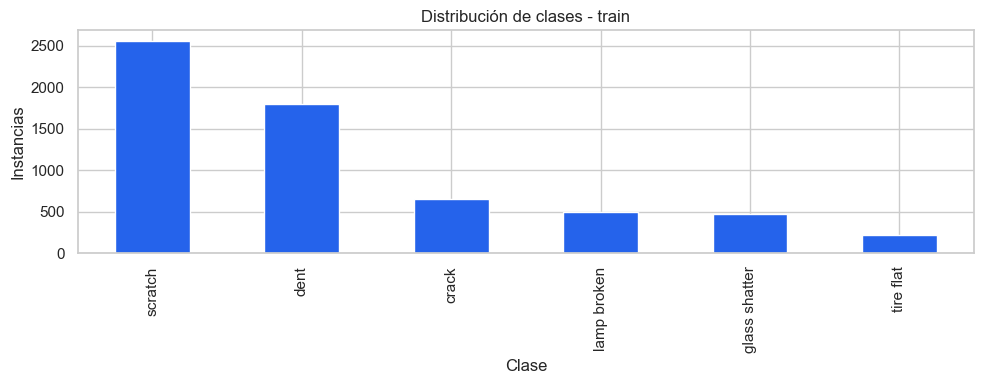

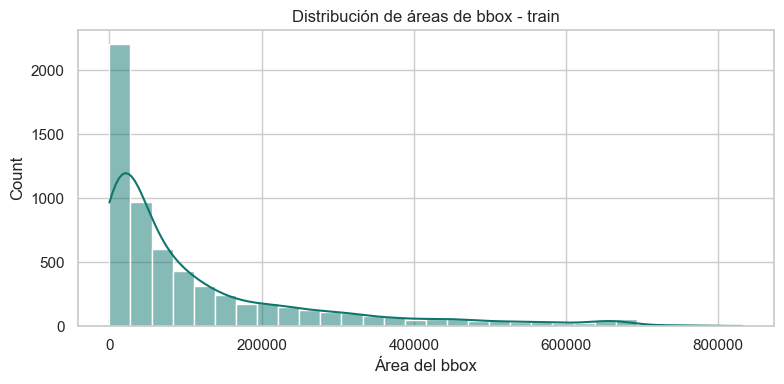

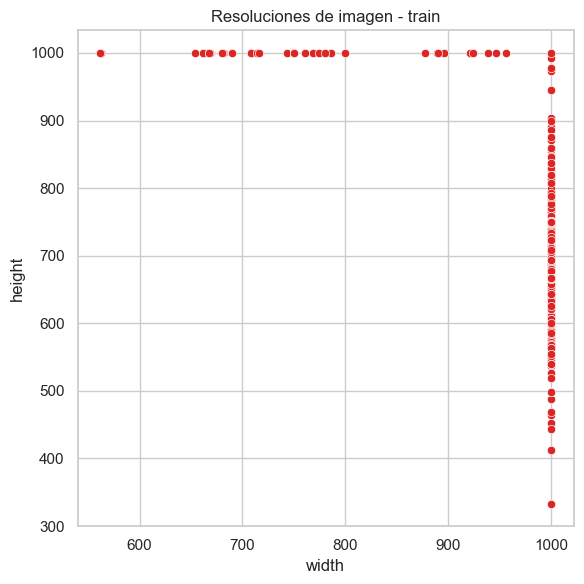

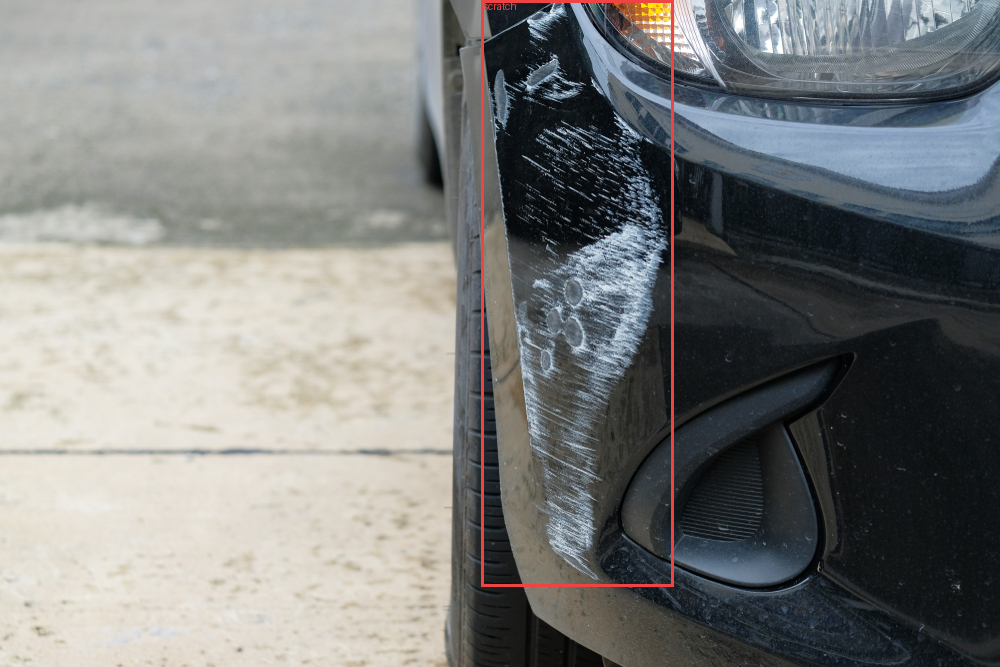

In [8]:
def resolve_image_path(file_name: str) -> Optional[Path]:
    if not file_name:
        return None
    direct = RAW_DATASET_DIR / file_name
    if direct.exists():
        return direct
    matches = list(RAW_DATASET_DIR.rglob(Path(file_name).name))
    return matches[0] if matches else None

def draw_annotations_on_image(image_path: Path, image_annotations: pd.DataFrame, category_color: str = "#ef4444") -> Optional[Image.Image]:
    if image_path is None or not image_path.exists():
        return None

    image = Image.open(image_path).convert("RGB")
    drawer = ImageDraw.Draw(image)

    for _, row in image_annotations.iterrows():
        bbox = row.get("bbox", None)
        if isinstance(bbox, list) and len(bbox) == 4:
            x, y, w, h = bbox
            drawer.rectangle((x, y, x + w, y + h), outline=category_color, width=3)
            label = str(row.get("category_name", row.get("category_id", "cls")))
            drawer.text((x + 2, max(0, y - 14)), label, fill=category_color)
    return image

if DATASET_READY and COCO_SPLIT_FRAMES:
    EDA_SUMMARY_DF.to_csv(METRICS_DIR / "eda_summary.csv", index=False)

    first_split = next(iter(COCO_SPLIT_FRAMES.keys()))
    images_df, ann_df, _ = COCO_SPLIT_FRAMES[first_split]

    plot_class_distribution(
        ann_df,
        title=f"Distribución de clases - {first_split}",
        save_path=FIGURES_DIR / f"class_distribution_{first_split}.png",
    )
    plot_bbox_area_distribution(
        ann_df,
        title=f"Distribución de áreas de bbox - {first_split}",
        save_path=FIGURES_DIR / f"bbox_area_{first_split}.png",
    )
    plot_resolution_distribution(
        images_df,
        title=f"Resoluciones de imagen - {first_split}",
        save_path=FIGURES_DIR / f"resolution_{first_split}.png",
    )

    if not images_df.empty and not ann_df.empty:
        sample_row = images_df.sample(n=1, random_state=SEED).iloc[0]
        image_annotations = ann_df[ann_df["image_id"] == sample_row["id"]] if "image_id" in ann_df.columns else ann_df.head(5)
        image_path = resolve_image_path(sample_row.get("file_name", ""))
        rendered = draw_annotations_on_image(image_path, image_annotations)
        if rendered is not None:
            display(rendered)
            rendered.save(FIGURES_DIR / f"sample_annotations_{first_split}.png")


## 6. Limpieza y Control de Calidad de Datos


In [9]:
def image_is_healthy(image_path: Path) -> bool:
    try:
        with Image.open(image_path) as image:
            image.verify()
        return True
    except Exception:
        return False

def safe_open_image(image_path: Path) -> Image.Image:
    image = Image.open(image_path)
    image = ImageOps.exif_transpose(image)
    if image.mode != "RGB":
        image = image.convert("RGB")
    return image

def clip_bbox_to_image(bbox: List[float], image_width: int, image_height: int) -> Optional[List[float]]:
    if not isinstance(bbox, list) or len(bbox) != 4:
        return None
    x, y, w, h = [float(v) for v in bbox]
    if w <= 0 or h <= 0:
        return None

    x1 = max(0.0, min(x, image_width))
    y1 = max(0.0, min(y, image_height))
    x2 = max(0.0, min(x + w, image_width))
    y2 = max(0.0, min(y + h, image_height))

    clipped_w = x2 - x1
    clipped_h = y2 - y1
    if clipped_w <= 0 or clipped_h <= 0:
        return None
    return [round(x1, 4), round(y1, 4), round(clipped_w, 4), round(clipped_h, 4)]

def polygon_is_valid(segmentation: Any, image_width: int, image_height: int) -> bool:
    if segmentation is None:
        return True
    if not isinstance(segmentation, list) or len(segmentation) == 0:
        return False

    valid_polygon_found = False
    for polygon in segmentation:
        if not isinstance(polygon, list) or len(polygon) < 6 or len(polygon) % 2 != 0:
            continue
        xs = polygon[0::2]
        ys = polygon[1::2]
        if min(xs) < 0 or min(ys) < 0:
            continue
        if max(xs) > image_width or max(ys) > image_height:
            continue
        valid_polygon_found = True
    return valid_polygon_found

def average_hash(image: Image.Image, hash_size: int = 8) -> str:
    reduced = image.convert("L").resize((hash_size, hash_size))
    pixels = np.asarray(reduced, dtype=np.float32)
    threshold = pixels.mean()
    bits = (pixels > threshold).astype(np.uint8).flatten().tolist()
    return "".join(map(str, bits))

def hamming_distance(hash_a: str, hash_b: str) -> int:
    return sum(ch1 != ch2 for ch1, ch2 in zip(hash_a, hash_b))

def image_quality_stats(image_path: Path) -> Dict[str, Any]:
    with safe_open_image(image_path) as image:
        image_array = np.asarray(image)
        gray = np.asarray(image.convert("L"), dtype=np.float32)
        laplacian_like = np.abs(np.diff(gray, axis=0)).mean() + np.abs(np.diff(gray, axis=1)).mean()
        return {
            "width": int(image.width),
            "height": int(image.height),
            "aspect_ratio": round(image.width / max(image.height, 1), 4),
            "mean_brightness": round(float(gray.mean()), 4),
            "std_brightness": round(float(gray.std()), 4),
            "sharpness_proxy": round(float(laplacian_like), 4),
            "a_hash": average_hash(image),
        }

def sanitize_annotation(
    annotation: Dict[str, Any],
    image_meta: Dict[str, Any],
    min_bbox_area_px: float = 9.0,
) -> Tuple[Optional[Dict[str, Any]], Optional[str]]:
    if annotation.get("category_id") is None:
        return None, "missing_category"

    clipped_bbox = clip_bbox_to_image(
        annotation.get("bbox", None),
        image_meta["width"],
        image_meta["height"],
    )
    if clipped_bbox is None:
        return None, "invalid_bbox"

    _, _, width, height = clipped_bbox
    area = width * height
    if area < min_bbox_area_px:
        return None, "tiny_bbox"

    segmentation = annotation.get("segmentation", None)
    if segmentation is not None and not polygon_is_valid(segmentation, image_meta["width"], image_meta["height"]):
        return None, "invalid_polygon"

    sanitized = dict(annotation)
    sanitized["bbox"] = clipped_bbox
    sanitized["area"] = round(float(area), 4)
    return sanitized, None

def clean_coco_payload(payload: Dict[str, Any]) -> Tuple[Dict[str, Any], Dict[str, Any]]:
    images = payload.get("images", [])
    annotations = payload.get("annotations", [])
    categories = payload.get("categories", [])

    valid_images = []
    valid_image_ids = set()
    dropped_images = []
    image_meta_map = {}

    for image in images:
        image_path = resolve_image_path(image.get("file_name", ""))
        if image_path is None or not image_path.exists():
            dropped_images.append({"reason": "missing_file", "image_id": image.get("id"), "file_name": image.get("file_name")})
            continue
        if not image_is_healthy(image_path):
            dropped_images.append({"reason": "corrupt_file", "image_id": image.get("id"), "file_name": image.get("file_name")})
            continue

        quality = image_quality_stats(image_path)
        sanitized_image = dict(image)
        sanitized_image["width"] = quality["width"]
        sanitized_image["height"] = quality["height"]
        valid_images.append(sanitized_image)
        valid_image_ids.add(image.get("id"))
        image_meta_map[image.get("id")] = {
            "file_name": image.get("file_name"),
            **quality,
        }

    valid_annotations = []
    dropped_annotations = []
    for annotation in annotations:
        image_id = annotation.get("image_id")
        if image_id not in valid_image_ids:
            dropped_annotations.append({"reason": "orphan_annotation", "annotation_id": annotation.get("id")})
            continue

        sanitized_annotation, reason = sanitize_annotation(annotation, image_meta_map[image_id])
        if sanitized_annotation is None:
            dropped_annotations.append({
                "reason": reason or "invalid_annotation",
                "annotation_id": annotation.get("id"),
                "image_id": image_id,
            })
            continue
        valid_annotations.append(sanitized_annotation)

    quality_df = pd.DataFrame(image_meta_map.values())
    report = {
        "input_images": len(images),
        "valid_images": len(valid_images),
        "dropped_images": len(dropped_images),
        "input_annotations": len(annotations),
        "valid_annotations": len(valid_annotations),
        "dropped_annotations": len(dropped_annotations),
        "avg_width": round(float(quality_df["width"].mean()), 2) if not quality_df.empty else None,
        "avg_height": round(float(quality_df["height"].mean()), 2) if not quality_df.empty else None,
        "avg_brightness": round(float(quality_df["mean_brightness"].mean()), 4) if not quality_df.empty else None,
        "avg_sharpness_proxy": round(float(quality_df["sharpness_proxy"].mean()), 4) if not quality_df.empty else None,
        "dark_images_lt40": int((quality_df["mean_brightness"] < 40).sum()) if not quality_df.empty else 0,
        "very_bright_images_gt215": int((quality_df["mean_brightness"] > 215).sum()) if not quality_df.empty else 0,
        "dropped_images_detail": dropped_images[:20],
        "dropped_annotations_detail": dropped_annotations[:20],
    }

    cleaned_payload = {
        "images": valid_images,
        "annotations": valid_annotations,
        "categories": categories,
    }
    return cleaned_payload, report

In [10]:
CLEANED_SPLIT_PAYLOADS = {}
CLEANING_REPORTS = {}

if DATASET_READY:
    for split_name, payload in COCO_SPLIT_PAYLOADS.items():
        cleaned_payload, report = clean_coco_payload(payload)
        CLEANED_SPLIT_PAYLOADS[split_name] = cleaned_payload
        CLEANING_REPORTS[split_name] = report
        output_path = INTERIM_DIR / f"{split_name}_clean.json"
        output_path.write_text(json.dumps(cleaned_payload, indent=2), encoding="utf-8")

    cleaning_report_path = PREPROCESS_DIR / "cleaning_report.json"
    cleaning_report_path.write_text(json.dumps(CLEANING_REPORTS, indent=2), encoding="utf-8")

CLEANING_REPORT_DF = pd.DataFrame(CLEANING_REPORTS).T if CLEANING_REPORTS else pd.DataFrame()
CLEANING_REPORT_DF

,input_images,valid_images,dropped_images,input_annotations,valid_annotations,dropped_annotations,avg_width,avg_height,avg_brightness,avg_sharpness_proxy,dark_images_lt40,very_bright_images_gt215,dropped_images_detail,dropped_annotations_detail
train,2816,2816,0,6211,6211,0,979.0,705.3,126.459,9.8872,6,6,[],[]
val,810,810,0,1744,1744,0,974.94,710.71,124.9551,10.2788,0,1,[],[]
test,374,374,0,785,785,0,977.75,702.91,127.6788,10.3491,0,2,[],[]


## 7. Preparación y Normalización


In [11]:
def build_category_name_map(payload: Dict[str, Any]) -> Dict[int, str]:
    return {int(cat["id"]): cat["name"] for cat in payload.get("categories", [])}

def object_scale_report(split_name: str, payload: Dict[str, Any]) -> pd.DataFrame:
    images_df = pd.DataFrame(payload.get("images", []))[["id", "width", "height", "file_name"]].rename(columns={"id": "image_id"})
    annotations_df = pd.DataFrame(payload.get("annotations", []))
    if images_df.empty or annotations_df.empty:
        return pd.DataFrame()

    bbox_df = pd.DataFrame(annotations_df["bbox"].tolist(), columns=["x", "y", "w", "h"])
    annotations_df = pd.concat([annotations_df.drop(columns=["bbox"]), bbox_df], axis=1)
    merged_df = annotations_df.merge(images_df, on="image_id", how="left")
    merged_df["bbox_area_px"] = merged_df["w"] * merged_df["h"]
    merged_df["image_area_px"] = merged_df["width"] * merged_df["height"]
    merged_df["bbox_area_ratio"] = merged_df["bbox_area_px"] / merged_df["image_area_px"].clip(lower=1)
    merged_df["scale_bucket"] = pd.cut(
        merged_df["bbox_area_ratio"],
        bins=[-np.inf, 0.01, 0.05, np.inf],
        labels=["small", "medium", "large"],
    )
    category_map = build_category_name_map(payload)
    merged_df["categoria"] = merged_df["category_id"].map(category_map).fillna("desconocida")
    merged_df["split"] = split_name
    return merged_df

OBJECT_SCALE_DF = pd.concat(
    [object_scale_report(split_name, payload) for split_name, payload in CLEANED_SPLIT_PAYLOADS.items()],
    ignore_index=True,
) if CLEANED_SPLIT_PAYLOADS else pd.DataFrame()

if not OBJECT_SCALE_DF.empty:
    OBJECT_SCALE_SUMMARY = (
        OBJECT_SCALE_DF.groupby(["split", "categoria", "scale_bucket"], observed=True)
        .size()
        .reset_index(name="instancias")
        .sort_values(["split", "categoria", "scale_bucket"])
        .reset_index(drop=True)
    )
    display(OBJECT_SCALE_SUMMARY)

    OBJECT_SCALE_STATS = (
        OBJECT_SCALE_DF.groupby(["split", "categoria"], observed=True)["bbox_area_ratio"]
        .agg(instancias="count", media="mean", p25=lambda s: s.quantile(0.25), p50="median", p75=lambda s: s.quantile(0.75))
        .reset_index()
        .sort_values(["split", "media"])
        .reset_index(drop=True)
    )
    display(OBJECT_SCALE_STATS.head(30))
else:
    OBJECT_SCALE_SUMMARY = pd.DataFrame()
    OBJECT_SCALE_STATS = pd.DataFrame()
    print("No se pudo generar el reporte de escala de objetos.")

,split,categoria,scale_bucket,instancias
0,test,crack,small,29
1,test,crack,medium,26
2,test,crack,large,15
3,test,dent,small,11
4,test,dent,medium,67
5,test,dent,large,158
6,test,glass shatter,medium,3
7,test,glass shatter,large,68
8,test,lamp broken,small,3
9,test,lamp broken,medium,11


,split,categoria,instancias,media,p25,p50,p75
0,test,crack,70,0.034324,0.004230,0.012784,0.034576
1,test,scratch,307,0.116967,0.027142,0.064927,0.148315
2,test,dent,236,0.134577,0.036499,0.085932,0.183895
3,test,lamp broken,69,0.195308,0.061070,0.185339,0.263575
4,test,tire flat,32,0.319715,0.173216,0.346932,0.397382
5,test,glass shatter,71,0.649522,0.447138,0.735810,0.879585
6,train,crack,651,0.031568,0.003619,0.009688,0.027671
7,train,scratch,2560,0.112390,0.019063,0.054203,0.147564
8,train,dent,1806,0.135896,0.032337,0.082557,0.185439
9,train,lamp broken,494,0.240267,0.091239,0.185859,0.352199


In [12]:
def build_image_quality_df(cleaned_payloads: Dict[str, Dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for split_name, payload in cleaned_payloads.items():
        for image in payload.get("images", []):
            image_path = resolve_image_path(image.get("file_name", ""))
            if image_path is None or not image_path.exists():
                continue
            stats = image_quality_stats(image_path)
            rows.append({
                "split": split_name,
                "image_id": image.get("id"),
                "file_name": image.get("file_name"),
                **stats,
            })
    return pd.DataFrame(rows)

IMAGE_QUALITY_DF = build_image_quality_df(CLEANED_SPLIT_PAYLOADS) if CLEANED_SPLIT_PAYLOADS else pd.DataFrame()

if not IMAGE_QUALITY_DF.empty:
    QUALITY_SUMMARY_DF = (
        IMAGE_QUALITY_DF.groupby("split")[["width", "height", "mean_brightness", "std_brightness", "sharpness_proxy"]]
        .agg(["mean", "median", "min", "max"])
        .round(3)
    )
    display(QUALITY_SUMMARY_DF)

    QUALITY_FLAGS_DF = IMAGE_QUALITY_DF.assign(
        low_light=lambda df: df["mean_brightness"] < 40,
        high_light=lambda df: df["mean_brightness"] > 215,
        low_sharpness=lambda df: df["sharpness_proxy"] < df["sharpness_proxy"].quantile(0.10),
    )
    display(
        QUALITY_FLAGS_DF.groupby("split")[["low_light", "high_light", "low_sharpness"]]
        .sum()
        .astype(int)
        .reset_index()
    )
else:
    QUALITY_SUMMARY_DF = pd.DataFrame()
    QUALITY_FLAGS_DF = pd.DataFrame()
    print("No se pudo construir el resumen de calidad de imagen.")

width                      height                   mean_brightness  \
          mean  median  min   max     mean median  min   max            mean   
split                                                                          
test   977.751  1000.0  563  1000  702.912  667.0  490  1000         127.679   
train  978.998  1000.0  562  1000  705.301  667.0  333  1000         126.459   
val    974.936  1000.0  562  1000  710.710  667.0  484  1000         124.955   

                                std_brightness                           \
        median     min      max           mean  median     min      max   
split                                                                     
test   127.371  43.336  229.104         61.868  61.884  23.846  112.491   
train  126.076  16.434  232.846         61.249  61.422  13.276  101.845   
val    124.916  40.519  220.932         60.341  60.234  17.292   97.725   

      sharpness_proxy                        
                 mean median    min     max  
split                                        
test           10.349  8.875  2.096  37.422  
train           9.887  8.723  1.754  47.854  
val            10.279  9.055  1.979  42.263

,split,low_light,high_light,low_sharpness
0,test,0,2,39
1,train,6,6,281
2,val,0,1,80


In [13]:
def find_cross_split_duplicates(image_quality_df: pd.DataFrame, max_hamming_distance: int = 0) -> pd.DataFrame:
    if image_quality_df.empty or "a_hash" not in image_quality_df.columns:
        return pd.DataFrame()

    candidate_rows = []
    rows = image_quality_df[["split", "image_id", "file_name", "a_hash"]].to_dict("records")
    for idx, left in enumerate(rows):
        for right in rows[idx + 1:]:
            if left["split"] == right["split"]:
                continue
            distance = hamming_distance(left["a_hash"], right["a_hash"])
            if distance <= max_hamming_distance:
                candidate_rows.append({
                    "split_left": left["split"],
                    "image_id_left": left["image_id"],
                    "file_left": left["file_name"],
                    "split_right": right["split"],
                    "image_id_right": right["image_id"],
                    "file_right": right["file_name"],
                    "hamming_distance": distance,
                })
    return pd.DataFrame(candidate_rows)

EXACT_DUPLICATES_DF = find_cross_split_duplicates(IMAGE_QUALITY_DF, max_hamming_distance=0)
NEAR_DUPLICATES_DF = find_cross_split_duplicates(IMAGE_QUALITY_DF, max_hamming_distance=3)

print(f"Duplicados exactos entre splits: {len(EXACT_DUPLICATES_DF)}")
if not EXACT_DUPLICATES_DF.empty:
    display(EXACT_DUPLICATES_DF.head(20))

print(f"Duplicados cercanos entre splits (distancia Hamming <= 3): {len(NEAR_DUPLICATES_DF)}")
if not NEAR_DUPLICATES_DF.empty:
    display(NEAR_DUPLICATES_DF.head(20))

Duplicados exactos entre splits: 3


,split_left,image_id_left,file_left,split_right,image_id_right,file_right,hamming_distance
0,train,2097,002097.jpg,val,2410,002410.jpg,0
1,train,3724,003724.jpg,val,1428,001428.jpg,0
2,train,3943,003943.jpg,test,3407,003407.jpg,0


Duplicados cercanos entre splits (distancia Hamming <= 3): 190


,split_left,image_id_left,file_left,split_right,image_id_right,file_right,hamming_distance
0,train,19,000019.jpg,val,1937,001937.jpg,3
1,train,19,000019.jpg,val,2817,002817.jpg,3
2,train,19,000019.jpg,val,3672,003672.jpg,2
3,train,19,000019.jpg,val,3711,003711.jpg,2
4,train,36,000036.jpg,test,23,000023.jpg,2
5,train,67,000067.jpg,val,1308,001308.jpg,2
6,train,116,000116.jpg,test,2448,002448.jpg,3
7,train,121,000121.jpg,val,1937,001937.jpg,3
8,train,338,000338.jpg,val,1531,001531.jpg,3
9,train,364,000364.jpg,val,1398,001398.jpg,3


### Ajustes de Preparación Experimental


### Uso de Particiones Oficiales


In [14]:
OFFICIAL_SPLIT_ORDER = ("train", "val", "test")


In [15]:
FINAL_SPLIT_PAYLOADS = {}

if DATASET_READY:
    missing_splits = [split_name for split_name in OFFICIAL_SPLIT_ORDER if split_name not in CLEANED_SPLIT_PAYLOADS]
    if missing_splits:
        raise ValueError(f"Faltan particiones oficiales después de la limpieza: {missing_splits}")

    FINAL_SPLIT_PAYLOADS = {
        split_name: CLEANED_SPLIT_PAYLOADS[split_name]
        for split_name in OFFICIAL_SPLIT_ORDER
    }

    split_manifest = {
        split_name: {
            "num_images": len(payload.get("images", [])),
            "num_annotations": len(payload.get("annotations", [])),
            "source": "official_cardd_coco",
        }
        for split_name, payload in FINAL_SPLIT_PAYLOADS.items()
    }
    (PREPROCESS_DIR / "splits.json").write_text(json.dumps(split_manifest, indent=2), encoding="utf-8")

pd.DataFrame(
    [
        {"split": split_name, "num_images": len(payload.get("images", [])), "num_annotations": len(payload.get("annotations", []))}
        for split_name, payload in FINAL_SPLIT_PAYLOADS.items()
    ]
)


,split,num_images,num_annotations
0,train,2816,6211
1,val,810,1744
2,test,374,785


In [16]:
def hardlink_or_copy(src: Path, dst: Path) -> None:
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        return
    try:
        os.link(src, dst)
    except Exception:
        shutil.copy2(src, dst)

def coco_bbox_to_yolo_line(annotation: Dict[str, Any], width: int, height: int, category_to_index: Dict[int, int]) -> str:
    x, y, w, h = annotation["bbox"]
    x_center = (x + w / 2.0) / width
    y_center = (y + h / 2.0) / height
    norm_w = w / width
    norm_h = h / height
    class_id = category_to_index[int(annotation["category_id"])]
    return f"{class_id} {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}"

def coco_segmentation_to_yolo_line(annotation: Dict[str, Any], width: int, height: int, category_to_index: Dict[int, int]) -> Optional[str]:
    segmentation = annotation.get("segmentation", None)
    if not isinstance(segmentation, list) or not segmentation:
        return None
    polygon = segmentation[0]
    if not isinstance(polygon, list) or len(polygon) < 6:
        return None
    coords = []
    for idx in range(0, len(polygon), 2):
        coords.append(f"{polygon[idx] / width:.6f} {polygon[idx + 1] / height:.6f}")
    class_id = category_to_index[int(annotation["category_id"])]
    return f"{class_id} " + " ".join(coords)

def export_processed_dataset(final_payloads: Dict[str, Dict[str, Any]]) -> Dict[str, Any]:
    if not final_payloads:
        return {}

    categories = final_payloads[next(iter(final_payloads.keys()))]["categories"]
    category_to_index = {int(cat["id"]): idx for idx, cat in enumerate(categories)}
    category_names = [cat["name"] for cat in categories]

    coco_dir = PROCESSED_DIR / "coco"
    yolo_det_dir = PROCESSED_DIR / "yolo_detection"
    yolo_seg_dir = PROCESSED_DIR / "yolo_segmentation"
    for path in [coco_dir, yolo_det_dir, yolo_seg_dir]:
        path.mkdir(parents=True, exist_ok=True)

    manifest = {"categories": category_names, "splits": {}}

    for split_name, payload in final_payloads.items():
        (coco_dir / f"{split_name}.json").write_text(json.dumps(payload, indent=2), encoding="utf-8")

        image_lookup = {img["id"]: img for img in payload.get("images", [])}
        anns_by_image: Dict[int, List[Dict[str, Any]]] = {}
        for ann in payload.get("annotations", []):
            anns_by_image.setdefault(int(ann["image_id"]), []).append(ann)

        det_image_dir = yolo_det_dir / "images" / split_name
        det_label_dir = yolo_det_dir / "labels" / split_name
        seg_image_dir = yolo_seg_dir / "images" / split_name
        seg_label_dir = yolo_seg_dir / "labels" / split_name

        det_image_dir.mkdir(parents=True, exist_ok=True)
        det_label_dir.mkdir(parents=True, exist_ok=True)
        seg_image_dir.mkdir(parents=True, exist_ok=True)
        seg_label_dir.mkdir(parents=True, exist_ok=True)

        for image_id, image_meta in image_lookup.items():
            source_path = resolve_image_path(image_meta.get("file_name", ""))
            if source_path is None:
                continue
            det_target_image = det_image_dir / Path(image_meta["file_name"]).name
            seg_target_image = seg_image_dir / Path(image_meta["file_name"]).name
            hardlink_or_copy(source_path, det_target_image)
            hardlink_or_copy(source_path, seg_target_image)

            det_lines = []
            seg_lines = []
            width = int(image_meta["width"])
            height = int(image_meta["height"])
            for annotation in anns_by_image.get(int(image_id), []):
                det_lines.append(coco_bbox_to_yolo_line(annotation, width, height, category_to_index))
                seg_line = coco_segmentation_to_yolo_line(annotation, width, height, category_to_index)
                if seg_line is not None:
                    seg_lines.append(seg_line)

            (det_label_dir / f"{det_target_image.stem}.txt").write_text("\n".join(det_lines), encoding="utf-8")
            (seg_label_dir / f"{seg_target_image.stem}.txt").write_text("\n".join(seg_lines), encoding="utf-8")

        manifest["splits"][split_name] = {
            "num_images": len(payload.get("images", [])),
            "num_annotations": len(payload.get("annotations", [])),
        }

    det_dataset_yaml = {
        "path": str(yolo_det_dir.resolve()),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": {idx: name for idx, name in enumerate(category_names)},
    }
    seg_dataset_yaml = {
        "path": str(yolo_seg_dir.resolve()),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": {idx: name for idx, name in enumerate(category_names)},
    }

    (yolo_det_dir / "dataset.yaml").write_text(yaml.safe_dump(det_dataset_yaml, sort_keys=False), encoding="utf-8")
    (yolo_seg_dir / "dataset.yaml").write_text(yaml.safe_dump(seg_dataset_yaml, sort_keys=False), encoding="utf-8")
    return manifest

PREPROCESS_MANIFEST = export_processed_dataset(FINAL_SPLIT_PAYLOADS) if FINAL_SPLIT_PAYLOADS else {}
if PREPROCESS_MANIFEST:
    (PREPROCESS_DIR / "preprocess_manifest.json").write_text(json.dumps(PREPROCESS_MANIFEST, indent=2), encoding="utf-8")
PREPROCESS_MANIFEST


{'categories': ['dent',
  'scratch',
  'crack',
  'glass shatter',
  'lamp broken',
  'tire flat'],
 'splits': {'train': {'num_images': 2816, 'num_annotations': 6211},
  'val': {'num_images': 810, 'num_annotations': 1744},
  'test': {'num_images': 374, 'num_annotations': 785}}}

## 8. Definición de Métricas

Para detección se reportan `mAP@0.5`, `mAP@0.5:0.95`, precisión, recall, F1, tiempo de inferencia y tiempo de entrenamiento.

Para segmentación se reportan `mAP` de máscaras, `mAP@0.5`, `mAP@0.5:0.95`, `IoU` promedio, precisión, recall y tiempos.

Se incluye además una evaluación homogénea tipo COCO-style aproximada dentro del propio notebook para facilitar comparación entre backends cuando `pycocotools` no esté disponible.


In [17]:
METRIC_REFERENCE_DF = pd.DataFrame(
    [
        {"task": "detection", "metric": "mAP@0.5", "meaning": "AP media a IoU 0.5", "limitation": "Menos exigente que COCO completo."},
        {"task": "detection", "metric": "mAP@0.5:0.95", "meaning": "AP media entre 0.5 y 0.95", "limitation": "Penaliza más localización imprecisa."},
        {"task": "detection", "metric": "precision", "meaning": "Proporción de predicciones correctas", "limitation": "Puede ocultar recall bajo."},
        {"task": "detection", "metric": "recall", "meaning": "Proporción de instancias recuperadas", "limitation": "Puede subir con más falsos positivos."},
        {"task": "segmentation", "metric": "mask_mAP@0.5:0.95", "meaning": "AP media de máscaras", "limitation": "Muy sensible a bordes."},
        {"task": "segmentation", "metric": "mean_IoU", "meaning": "Solapamiento medio", "limitation": "No capta ranking por confianza por sí solo."},
        {"task": "general", "metric": "inference_time_ms", "meaning": "Latencia por imagen", "limitation": "Depende del hardware."},
        {"task": "general", "metric": "training_time_min", "meaning": "Costo temporal de entrenamiento", "limitation": "No garantiza mejor generalización."},
    ]
)
IOU_THRESHOLDS = np.arange(0.5, 1.0, 0.05)
METRIC_REFERENCE_DF


,task,metric,meaning,limitation
0,detection,mAP@0.5,AP media a IoU 0.5,Menos exigente que COCO completo.
1,detection,mAP@0.5:0.95,AP media entre 0.5 y 0.95,Penaliza más localización imprecisa.
2,detection,precision,Proporción de predicciones correctas,Puede ocultar recall bajo.
3,detection,recall,Proporción de instancias recuperadas,Puede subir con más falsos positivos.
4,segmentation,mask_mAP@0.5:0.95,AP media de máscaras,Muy sensible a bordes.
5,segmentation,mean_IoU,Solapamiento medio,No capta ranking por confianza por sí solo.
6,general,inference_time_ms,Latencia por imagen,Depende del hardware.
7,general,training_time_min,Costo temporal de entrenamiento,No garantiza mejor generalización.


## 9. Configuración Experimental Global


In [18]:
GLOBAL_EXPERIMENT_CONFIG = {
    "seed": CONFIG["random_seed"],
    "device": DEVICE_INFO["device"],
    "amp_enabled": CONFIG["amp_enabled"],
    "target_gpu_profile": CONFIG["target_gpu_profile"],
    "det_batch_size": CONFIG["detection_batch_size"],
    "seg_batch_size": CONFIG["segmentation_batch_size"],
    "imgsz_default": CONFIG["default_image_size"],
    "workers": CONFIG["default_num_workers"],
    "conf_threshold_default": 0.25,
    "iou_threshold_default": 0.50,
    "artifacts": {key: str(value) for key, value in MODEL_ARTIFACTS.items()},
}
print("Experimento global | device:", GLOBAL_EXPERIMENT_CONFIG["device"], "| amp:", GLOBAL_EXPERIMENT_CONFIG["amp_enabled"])


Experimento global | device: cuda:0 | amp: True


## 10. Integración con MLflow


In [19]:
if mlflow is not None:
    mlflow.set_tracking_uri(CONFIG["mlflow_tracking_uri"])
    mlflow.set_experiment(CONFIG["mlflow_experiment_name"])
    print("MLflow configurado en:", CONFIG["mlflow_tracking_uri"])
else:
    print("MLflow no está disponible en el entorno actual.")

def flatten_dict(prefix: str, payload: Dict[str, Any]) -> Dict[str, Any]:
    flattened = {}
    for key, value in payload.items():
        new_key = f"{prefix}.{key}" if prefix else key
        if isinstance(value, dict):
            flattened.update(flatten_dict(new_key, value))
        else:
            flattened[new_key] = value
    return flattened

import importlib, notebook_training_helpers as _nth
importlib.reload(_nth)
from notebook_training_helpers import (
    annotation_to_binary_mask,
    build_category_metadata,
    build_faster_rcnn_model,
    build_mask_rcnn_model,
    build_torchvision_target,
    build_optimizer,
    train_torchvision_model,
    CarDDTorchvisionDataset,
    torchvision_collate_fn,
)

TRAINING_EXECUTION = {
    "run_all"           : False,
    "yolov8_det"        : False,   # ya entrenado — no re-entrenar
    "faster_rcnn"       : True,  # ya entrenado — no re-entrenar
    "yolov8_seg"        : False,   # ya entrenado — no re-entrenar
    "mask_rcnn"         : True,  # ya entrenado — no re-entrenar
    "run_tuning"        : True,
    "run_error_analysis": True,
}

CATEGORY_METADATA = build_category_metadata(
    FINAL_SPLIT_PAYLOADS["train"]["categories"] if FINAL_SPLIT_PAYLOADS else []
)
TORCH_LABEL_TO_CATEGORY_ID = {
    torch_label: category_id for category_id, torch_label in CATEGORY_METADATA.get("id_to_torchvision_label", {}).items()
}
CATEGORY_ID_TO_NAME = {int(cat["id"]): cat["name"] for cat in FINAL_SPLIT_PAYLOADS["train"]["categories"]} if FINAL_SPLIT_PAYLOADS else {}

def should_execute_training(model_id: str) -> bool:
    default_execute = bool(TRAINING_EXECUTION.get("run_all", False))
    return bool(TRAINING_EXECUTION.get(model_id, default_execute))

@contextmanager
def maybe_mlflow_run(model_id: str, task_type: str, config: Dict[str, Any], nested: bool = False):
    if mlflow is None:
        yield None
        return
    with mlflow.start_run(run_name=f"{model_id}_{task_type}", nested=nested) as run:
        mlflow.log_params(flatten_dict("", config))
        mlflow.log_param("model_id", model_id)
        mlflow.log_param("task_type", task_type)
        mlflow.log_dict(DEVICE_INFO, artifact_file=f"{model_id}_device.json")
        yield run

def log_history_to_mlflow(history: List[Dict[str, Any]]) -> None:
    if mlflow is None:
        return
    for row in history:
        step = int(row.get("epoch", 0))
        metrics = {key: float(value) for key, value in row.items() if key != "epoch" and isinstance(value, (int, float))}
        if metrics:
            mlflow.log_metrics(metrics, step=step)



def load_run_summary_from_mlflow(
    model_id: str,
    task_type: str,
    metric_key: str = "val_map50",
) -> Optional[Dict[str, Any]]:
    """Reconstruye run_summary desde MLflow eligiendo el MEJOR run por metrica
    (no el mas reciente). Para Faster/Mask R-CNN recupera el max real de val_map50
    sobre todo el historial de epocas via get_metric_history; para YOLO (donde
    val_map50 no se loguea por epoca) selecciona el run mas reciente.

    Claves populadas:
      train_time_s   -> metrica final logueada por train_*
      stable_output  -> param output_path logueado via flatten_dict(config)
      best_val_map50 -> max real sobre historial de pasos (R-CNN) o None (YOLO)
      best_epoch     -> step del max (R-CNN) o None (YOLO)
      history_csv    -> METRICS_DIR/{model_id}_training_history.csv si existe en disco
      history_json   -> METRICS_DIR/{model_id}_training_history.json si existe en disco
    Claves NO populadas (no logueadas y no usadas downstream):
      history        -> lista de dicts por epoca; no se reconstruye
      results        -> str de ultralytics, no logueado
    """
    if mlflow is None:
        print(f"[WARN] MLflow no disponible; no se puede recuperar run de {model_id}.")
        return None

    from mlflow.tracking import MlflowClient
    client = MlflowClient()
    experiment = client.get_experiment_by_name(CONFIG["mlflow_experiment_name"])
    if experiment is None:
        print(f"[WARN] Experimento '{CONFIG['mlflow_experiment_name']}' no encontrado en MLflow.")
        return None

    run_name = f"{model_id}_{task_type}"
    all_runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        order_by=["start_time DESC"],
    )
    matching = [r for r in all_runs if r.data.tags.get("mlflow.runName") == run_name]
    if not matching:
        print(f"[WARN] No se encontro ningun run para '{run_name}' en MLflow.")
        return None

    # Para cada run recupera el max real del metric_key via historial completo de pasos.
    # Necesario porque run.data.metrics solo da el ultimo valor logueado, no el mejor
    # (early stopping para despues del pico: el ultimo != el maximo).
    def best_metric_for_run(r):
        try:
            hist = client.get_metric_history(r.info.run_id, metric_key)
            if hist:
                return max(m.value for m in hist)
        except Exception:
            pass
        v = r.data.metrics.get(metric_key)
        return v if v is not None else float("-inf")

    best_run = max(matching, key=best_metric_for_run)
    best_metric_val = best_metric_for_run(best_run)
    display_val = f"{best_metric_val:.4f}" if best_metric_val > float("-inf") else "N/A"
    print(f"[{model_id}] runs encontrados: {len(matching)} | mejor {metric_key}={display_val} | run_id={best_run.info.run_id[:8]}")

    summary: Dict[str, Any] = {"run_id": best_run.info.run_id}

    # train_time_s — unica clave consumida downstream via safe_training_minutes()
    train_time_s = best_run.data.metrics.get("train_time_s")
    if train_time_s is not None:
        summary["train_time_s"] = float(train_time_s)
    else:
        print(f"[WARN] 'train_time_s' no encontrado para '{run_name}'; training_time_min sera NaN.")

    # stable_output — logueado como param via flatten_dict("", config) en maybe_mlflow_run
    stable_output = best_run.data.params.get("output_path")
    if stable_output:
        summary["stable_output"] = stable_output
    else:
        print(f"[WARN] 'output_path' no encontrado en params de '{run_name}'.")

    # best_val_map50 + best_epoch — del historial real (R-CNN); None para YOLO
    if best_metric_val > float("-inf"):
        try:
            hist = client.get_metric_history(best_run.info.run_id, metric_key)
            if hist:
                best_step = max(hist, key=lambda m: m.value)
                summary["best_val_map50"] = best_step.value
                summary["best_epoch"]     = best_step.step
        except Exception:
            summary["best_val_map50"] = best_metric_val

    # history_csv / history_json — escritos en disco por save_training_history
    csv_path  = METRICS_DIR / f"{model_id}_training_history.csv"
    json_path = METRICS_DIR / f"{model_id}_training_history.json"
    if csv_path.exists():
        summary["history_csv"]  = str(csv_path)
    if json_path.exists():
        summary["history_json"] = str(json_path)

    return summary

print("Control de entrenamiento:", TRAINING_EXECUTION)


MLflow configurado en: file:c:/proyectos python/Tesis 2026/Proyecto/mlruns
Control de entrenamiento: {'run_all': False, 'yolov8_det': False, 'faster_rcnn': True, 'yolov8_seg': False, 'mask_rcnn': True, 'run_tuning': True, 'run_error_analysis': True}


In [20]:
from sklearn.cluster import KMeans

def compute_kmeans_anchor_sizes(train_payload, imgsz=640, k=5, seed=SEED):
    """K-Means en escala logarítmica sobre sqrt(w*h) de las cajas de train,
    escaladas al tamaño que ve el modelo (misma lógica que resize_pil_and_target:
    lado mayor -> imgsz).

    Se usa log-space en vez de escala lineal porque K-Means euclidiano sobre
    tamaños en escala lineal se sesga hacia los valores grandes cuando la
    distribución tiene cola larga (CarDD: ~16 a ~500+). Es la misma razón por
    la que YOLOv2 no usa K-Means euclidiano directo sobre tamaño de caja sino
    una métrica basada en IoU; acá se aproxima con log-space, que da peso
    proporcional a cada orden de magnitud en vez de a la diferencia absoluta.
    """
    images_by_id = {int(img["id"]): img for img in train_payload["images"]}
    scaled_sizes = []
    for ann in train_payload["annotations"]:
        img_meta = images_by_id[int(ann["image_id"])]
        scale = imgsz / max(int(img_meta["width"]), int(img_meta["height"]))
        _, _, w, h = ann["bbox"]
        if w <= 0 or h <= 0:
            continue
        scaled_sizes.append(np.sqrt((w * scale) * (h * scale)))

    sizes_arr = np.array(scaled_sizes)
    print(
        "Percentiles de tamaño de caja (sqrt(w*h), escalados a imgsz):",
        {p: round(float(np.percentile(sizes_arr, p)), 1) for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]},
    )

    log_sizes = np.log(sizes_arr).reshape(-1, 1)
    km = KMeans(n_clusters=k, random_state=seed, n_init=10).fit(log_sizes)
    centers = sorted(np.exp(km.cluster_centers_.flatten()).tolist())
    anchor_sizes = tuple(int(round(c)) for c in centers)

    frac_below_min = float((sizes_arr < min(anchor_sizes)).mean() * 100)
    print(f"Porcentaje de cajas más chicas que el ancla mínima nueva ({min(anchor_sizes)}): {frac_below_min:.1f}%")
    frac_below_old = float((sizes_arr < 58).mean() * 100)
    print(f"(referencia) Porcentaje de cajas más chicas que el ancla mínima anterior (58): {frac_below_old:.1f}%")

    return anchor_sizes

CARDD_ANCHOR_SIZES = compute_kmeans_anchor_sizes(FINAL_SPLIT_PAYLOADS["train"], imgsz=640, k=5)
print("Anchor sizes por K-Means en escala lineal (versión anterior): (58, 134, 220, 329, 464)")
print("Anchor sizes por K-Means en escala logarítmica (nuevo):", CARDD_ANCHOR_SIZES)

Percentiles de tamaño de caja (sqrt(w*h), escalados a imgsz): {1: 16.4, 5: 33.1, 10: 45.9, 25: 79.8, 50: 147.0, 75: 250.7, 90: 366.2, 95: 437.0, 99: 522.7}
Porcentaje de cajas más chicas que el ancla mínima nueva (25): 2.7%
(referencia) Porcentaje de cajas más chicas que el ancla mínima anterior (58): 15.4%
Anchor sizes por K-Means en escala lineal (versión anterior): (58, 134, 220, 329, 464)
Anchor sizes por K-Means en escala logarítmica (nuevo): (25, 57, 111, 199, 367)


## 11.1 YOLOv8n


In [21]:
YOLOV8_DET_CONFIG = {
    "task": "detection",
    "architecture_family": "cnn_one_stage",
    "weights_init": "yolov8n.pt",
    "epochs": 100,
    "imgsz": 640 if DEVICE_INFO["cuda_available"] else 512,
    "batch": 8 if DEVICE_INFO["cuda_available"] else 1,
    "optimizer": "SGD",
    "lr0": 0.01,
    "lrf": 0.01,
    "momentum": 0.937,
    "weight_decay": 0.0005,
    "patience": 30,
    "workers": CONFIG["default_num_workers"],
    "conf_threshold": 0.25,
    "iou_threshold": 0.50,
    "close_mosaic": 20,
    "cos_lr": True,
    "amp": bool(DEVICE_INFO["cuda_available"]),
    "cache": False,
    "degrees": 5.0,
    "translate": 0.1,
    "scale": 0.5,
    "fliplr": 0.5,
    "flipud": 0.0,
    "hsv_h": 0.015,
    "hsv_s": 0.7,
    "hsv_v": 0.4,
    "erasing": 0.4,
    "data_yaml": str((PROCESSED_DIR / "yolo_detection" / "dataset.yaml").resolve()),
    "output_path": str(MODEL_ARTIFACTS["yolov8_det"]),
}
YOLOV8_DET_CONFIG


{'task': 'detection',
 'architecture_family': 'cnn_one_stage',
 'weights_init': 'yolov8n.pt',
 'epochs': 100,
 'imgsz': 640,
 'batch': 8,
 'optimizer': 'SGD',
 'lr0': 0.01,
 'lrf': 0.01,
 'momentum': 0.937,
 'weight_decay': 0.0005,
 'patience': 30,
 'workers': 0,
 'conf_threshold': 0.25,
 'iou_threshold': 0.5,
 'close_mosaic': 20,
 'cos_lr': True,
 'amp': True,
 'cache': False,
 'degrees': 5.0,
 'translate': 0.1,
 'scale': 0.5,
 'fliplr': 0.5,
 'flipud': 0.0,
 'hsv_h': 0.015,
 'hsv_s': 0.7,
 'hsv_v': 0.4,
 'erasing': 0.4,
 'data_yaml': 'C:\\proyectos python\\Tesis 2026\\Proyecto\\data\\processed\\yolo_detection\\dataset.yaml',
 'output_path': 'c:\\proyectos python\\Tesis 2026\\Proyecto\\artifacts\\models\\yolov8_det.pt'}

### Entrenamiento de YOLOv8n


In [ ]:
def train_yolov8_det(config: Dict[str, Any], execute: bool = False) -> Optional[Dict[str, Any]]:
    if not execute:
        print("Entrenamiento omitido. Ajuste el control global TRAINING_EXECUTION si desea ejecutar YOLOv8-det.")
        return None
    if ultralytics is None:
        raise ImportError("Ultralytics no está instalado.")
    from ultralytics import YOLO

    with maybe_mlflow_run("yolov8_det", config["task"], config):
        model = YOLO(config["weights_init"])
        start_time = time.perf_counter()
        results = model.train(
            data=config["data_yaml"],
            epochs=config["epochs"],
            imgsz=config["imgsz"],
            batch=config["batch"],
            workers=config["workers"],
            lr0=config["lr0"],
            lrf=config.get("lrf", 0.01),
            momentum=config.get("momentum", 0.937),
            optimizer=config["optimizer"],
            weight_decay=config["weight_decay"],
            patience=config["patience"],
            close_mosaic=config["close_mosaic"],
            cos_lr=config["cos_lr"],
            amp=config["amp"],
            cache=config["cache"],
            degrees=config["degrees"],
            translate=config["translate"],
            scale=config["scale"],
            fliplr=config["fliplr"],
            flipud=config["flipud"],
            hsv_h=config["hsv_h"],
            hsv_s=config["hsv_s"],
            hsv_v=config["hsv_v"],
            erasing=config.get("erasing", 0.4),
            seed=CONFIG["random_seed"],
            deterministic=True,
            device=0 if DEVICE_INFO["cuda_available"] else "cpu",
            project=str(ARTIFACTS_DIR / "runs"),
            name="yolov8_det_train",
            exist_ok=True,
        )
        elapsed_seconds = time.perf_counter() - start_time
        best_path = Path(model.trainer.best)
        shutil.copy2(best_path, config["output_path"])
        run_summary = {
            "best_path": str(best_path),
            "stable_output": config["output_path"],
            "train_time_s": elapsed_seconds,
            "results": str(results),
        }
        if mlflow is not None and best_path.exists():
            mlflow.log_artifact(str(best_path))
            mlflow.log_artifact(config["output_path"])
            mlflow.log_metric("train_time_s", elapsed_seconds)
    return run_summary

YOLOV8_DET_RUN = train_yolov8_det(YOLOV8_DET_CONFIG, execute=should_execute_training("yolov8_det"))
if YOLOV8_DET_RUN is None:
    YOLOV8_DET_RUN = load_run_summary_from_mlflow("yolov8_det", "detection")


New https://pypi.org/project/ultralytics/8.4.92 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.102  Python-3.11.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=C:\proyectos python\Tesis 2026\Proyecto\data\processed\yolo_detection\dataset.yaml, epochs=100, time=None, patience=30, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=0, project=c:\proyectos python\Tesis 2026\Proyecto\artifacts\runs, name=yolov8_det_train, exist_ok=True, pretrained=True, optimizer=SGD, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=20, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False

train: Scanning C:\proyectos python\Tesis 2026\Proyecto\data\processed\yolo_detection\labels\train.cache... 2816 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2816/2816 [00:00<?, ?it/s]


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Scanning C:\proyectos python\Tesis 2026\Proyecto\data\processed\yolo_detection\labels\val.cache... 810 images, 0 backgrounds, 0 corrupt: 100%|██████████| 810/810 [00:00<?, ?it/s]


Plotting labels to c:\proyectos python\Tesis 2026\Proyecto\artifacts\runs\yolov8_det_train\labels.jpg... 
optimizer: SGD(lr=0.01, momentum=0.937) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
MLflow: logging run_id(ff445b39f6944d20a1d524361c776dc1) to file:c:/proyectos python/Tesis 2026/Proyecto/mlruns
MLflow: disable with 'yolo settings mlflow=False'
MLflow: WARNING  Failed to initialize: Changing param values is not allowed. Param with key='task' was already logged with value='detection' for run ID='ff445b39f6944d20a1d524361c776dc1'. Attempted logging new value 'detect'.
MLflow: WARNING  Not tracking this run
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to c:\proyectos python\Tesis 2026\Proyecto\artifacts\runs\yolov8_det_train
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

    100/100      1.35G     0.9365     0.7832      1.179         18        640: 100%|██████████| 352/352 [01:35<00:00,  3.67it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 51/51 [00:14<00:00,  3.46it/s]

                   all        810       1744      0.751      0.655      0.701      0.516



100 epochs completed in 3.183 hours.
Optimizer stripped from c:\proyectos python\Tesis 2026\Proyecto\artifacts\runs\yolov8_det_train\weights\last.pt, 6.3MB
Optimizer stripped from c:\proyectos python\Tesis 2026\Proyecto\artifacts\runs\yolov8_det_train\weights\best.pt, 6.3MB

Validating c:\proyectos python\Tesis 2026\Proyecto\artifacts\runs\yolov8_det_train\weights\best.pt...
Ultralytics 8.3.102  Python-3.11.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 51/51 [00:15<00:00,  3.21it/s]


                   all        810       1744      0.751      0.655      0.702      0.519
                  dent        352        501      0.646      0.483      0.553      0.294
               scratch        431        728      0.658      0.483      0.539      0.286
                 crack        122        177      0.504      0.316      0.315      0.132
         glass shatter        134        135       0.98      0.963      0.991      0.897
           lamp broken        139        141      0.821      0.814      0.858      0.669
             tire flat         59         62      0.899      0.871      0.956      0.836
Speed: 0.3ms preprocess, 3.9ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to c:\proyectos python\Tesis 2026\Proyecto\artifacts\runs\yolov8_det_train
MLflow: results logged to file:c:/proyectos python/Tesis 2026/Proyecto/mlruns
MLflow: disable with 'yolo settings mlflow=False'


In [ ]:
while mlflow.active_run() is not None:
    mlflow.end_run()

## 11.2 Faster R-CNN


In [22]:
FASTERRCNN_CONFIG = {
    "task"                       : "detection",
    "architecture_family"        : "cnn_two_stage",
    "weights_init"               : "DEFAULT",
    "epochs"                     : 50,
    "imgsz"                      : 640 if DEVICE_INFO["cuda_available"] else 512,
    "max_size"                   : 1024,
    "batch"                      : 1,
    "optimizer"                  : "AdamW",
    "lr"                         : 5e-4,   # revertido — 3e-4 quedó peor que baseline
    "weight_decay"               : 5e-4,   # revertido
    "patience"                   : 10,
    "min_delta"                  : 1e-4,
    "gradient_accumulation_steps": 4 if DEVICE_INFO["cuda_available"] else 1,
    "clip_grad_norm"             : 1.0,
    "workers"                    : CONFIG["default_num_workers"],
    "amp"                        : bool(DEVICE_INFO["cuda_available"]),
    "trainable_backbone_layers"  : 2,      # revertido — el bracket en 1 no superó la config ganadora
    "scheduler"                  : "cosine",
    "warmup_epochs"              : 5,
    "layerwise_lr"               : True,
    "backbone_lr_mult"           : 0.2,
    "augment"                    : True,
    "conf_threshold"             : 0.4,   # antes 0.25 — ajuste post-hoc justificado por distribución de scores de FP
    "anchor_aspect_ratios"       : (0.25, 0.5, 1.0, 2.0, 4.0),
    "box_detections_per_img"     : 200,
    "output_path"                : str(MODEL_ARTIFACTS["faster_rcnn"]),
    "anchor_sizes"               : CARDD_ANCHOR_SIZES,
    "rpn_pre_nms_top_n_train"    : 3000,
    "rpn_post_nms_top_n_train"   : 2000,
    "rpn_pre_nms_top_n_test"     : 1500,
    "rpn_post_nms_top_n_test"    : 1000,
    "box_nms_thresh"             : 0.5,
    "hard_negative_start_epoch"   : 0,   # época en la que se minan FP confiados sobre fondo y se cambia el sampler; el mejor run (0.548) estabilizó cerca de la época 16, así que 12 deja margen para que el resto del entrenamiento aproveche el reweighting
    "hard_negative_score_thresh"  : 0.5,
    "hard_negative_oversample"    : 3.0,
    "box_positive_fraction": 0.5,   # default torchvision=0.25
    "swa_enabled"          : True,
    "swa_start_epoch"      : 16,
    "swa_epochs"           : 8,
    "swa_lr"                : 1e-5,
}


In [24]:

def train_faster_rcnn(config: Dict[str, Any], execute: bool = False) -> Optional[Dict[str, Any]]:
    if not execute:
        print("Entrenamiento omitido. Active TRAINING_EXECUTION['faster_rcnn']=True para ejecutar Faster R-CNN.")
        return None
    with maybe_mlflow_run("faster_rcnn", config["task"], config):
        model = build_faster_rcnn_model(config, CATEGORY_METADATA)
        start_time = time.perf_counter()
        run_summary = train_torchvision_model(
            model=model,
            config=config,
            model_id="faster_rcnn",
            task_type="detection",
            processed_dir=PROCESSED_DIR,
            metrics_dir=METRICS_DIR,
            device_info=DEVICE_INFO,
            category_metadata=CATEGORY_METADATA,
            resolve_image_path_fn=resolve_image_path,
        )
        elapsed_seconds = time.perf_counter() - start_time
        run_summary["train_time_s"] = elapsed_seconds
        if mlflow is not None:
            log_history_to_mlflow(run_summary.get("history", []))
            for artifact_key in ["stable_output", "history_csv", "history_json"]:
                artifact_path = run_summary.get(artifact_key)
                if artifact_path and Path(artifact_path).exists():
                    mlflow.log_artifact(artifact_path)
            mlflow.log_metric("train_time_s", elapsed_seconds)
        return run_summary

FASTERRCNN_RUN = train_faster_rcnn(FASTERRCNN_CONFIG, execute=should_execute_training("faster_rcnn"))
if FASTERRCNN_RUN is None:
    FASTERRCNN_RUN = load_run_summary_from_mlflow("faster_rcnn", "detection")
FASTERRCNN_CONFIG


[faster_rcnn] epoch=1/50 train_loss=0.5739 val_loss=0.3507 val_mAP50=0.0011 lr_backbone=0.000021 lr_head=0.000104
[faster_rcnn] epoch=2/50 train_loss=0.3282 val_loss=0.2946 val_mAP50=0.4580 lr_backbone=0.000041 lr_head=0.000203
[faster_rcnn] epoch=3/50 train_loss=0.2959 val_loss=0.2936 val_mAP50=0.5166 lr_backbone=0.000060 lr_head=0.000302
[faster_rcnn] epoch=4/50 train_loss=0.2986 val_loss=0.3019 val_mAP50=0.5261 lr_backbone=0.000080 lr_head=0.000401
[faster_rcnn] epoch=5/50 train_loss=0.3035 val_loss=0.3192 val_mAP50=0.5410 lr_backbone=0.000100 lr_head=0.000500
[faster_rcnn] epoch=6/50 train_loss=0.2973 val_loss=0.2962 val_mAP50=0.5434 lr_backbone=0.000100 lr_head=0.000499
[faster_rcnn] epoch=7/50 train_loss=0.2882 val_loss=0.3106 val_mAP50=0.5142 lr_backbone=0.000100 lr_head=0.000498
[faster_rcnn] epoch=8/50 train_loss=0.2660 val_loss=0.3210 val_mAP50=0.4600 lr_backbone=0.000099 lr_head=0.000495
[faster_rcnn] epoch=9/50 train_loss=0.2551 val_loss=0.3186 val_mAP50=0.5173 lr_backbone=

{'task': 'detection',
 'architecture_family': 'cnn_two_stage',
 'weights_init': 'DEFAULT',
 'epochs': 50,
 'imgsz': 640,
 'max_size': 1024,
 'batch': 1,
 'optimizer': 'AdamW',
 'lr': 0.0005,
 'weight_decay': 0.0005,
 'patience': 10,
 'min_delta': 0.0001,
 'gradient_accumulation_steps': 4,
 'clip_grad_norm': 1.0,
 'workers': 0,
 'amp': True,
 'trainable_backbone_layers': 2,
 'scheduler': 'cosine',
 'warmup_epochs': 5,
 'layerwise_lr': True,
 'backbone_lr_mult': 0.2,
 'augment': True,
 'conf_threshold': 0.4,
 'anchor_aspect_ratios': (0.25, 0.5, 1.0, 2.0, 4.0),
 'box_detections_per_img': 200,
 'output_path': 'c:\\proyectos python\\Tesis 2026\\Proyecto\\artifacts\\models\\faster_rcnn.pth',
 'anchor_sizes': (25, 57, 111, 199, 367),
 'rpn_pre_nms_top_n_train': 3000,
 'rpn_post_nms_top_n_train': 2000,
 'rpn_pre_nms_top_n_test': 1500,
 'rpn_post_nms_top_n_test': 1000,
 'box_nms_thresh': 0.5,
 'hard_negative_start_epoch': 0,
 'hard_negative_score_thresh': 0.5,
 'hard_negative_oversample': 3.0,


## 11.3 YOLOv8n-seg


In [27]:
YOLOV8_SEG_CONFIG = {
    "task": "segmentation",
    "architecture_family": "cnn_one_stage",
    "weights_init": "yolov8n-seg.pt",
    "epochs": 100,
    "imgsz": 640 if DEVICE_INFO["cuda_available"] else 512,
    "batch": 4 if DEVICE_INFO["cuda_available"] else 1,
    "optimizer": "SGD",
    "lr0": 0.01,
    "lrf": 0.01,
    "momentum": 0.937,
    "weight_decay": 0.0005,
    "patience": 30,
    "workers": CONFIG["default_num_workers"],
    "conf_threshold": 0.25,
    "iou_threshold": 0.50,
    "close_mosaic": 20,
    "cos_lr": True,
    "amp": bool(DEVICE_INFO["cuda_available"]),
    "cache": False,
    "degrees": 5.0,
    "translate": 0.1,
    "scale": 0.5,
    "fliplr": 0.5,
    "flipud": 0.0,
    "hsv_h": 0.015,
    "hsv_s": 0.7,
    "hsv_v": 0.4,
    "erasing": 0.4,
    "overlap_mask": True,
    "data_yaml": str((PROCESSED_DIR / "yolo_segmentation" / "dataset.yaml").resolve()),
    "output_path": str(MODEL_ARTIFACTS["yolov8_seg"]),
}
YOLOV8_SEG_CONFIG


{'task': 'segmentation',
 'architecture_family': 'cnn_one_stage',
 'weights_init': 'yolov8n-seg.pt',
 'epochs': 100,
 'imgsz': 640,
 'batch': 4,
 'optimizer': 'SGD',
 'lr0': 0.01,
 'lrf': 0.01,
 'momentum': 0.937,
 'weight_decay': 0.0005,
 'patience': 30,
 'workers': 0,
 'conf_threshold': 0.25,
 'iou_threshold': 0.5,
 'close_mosaic': 20,
 'cos_lr': True,
 'amp': True,
 'cache': False,
 'degrees': 5.0,
 'translate': 0.1,
 'scale': 0.5,
 'fliplr': 0.5,
 'flipud': 0.0,
 'hsv_h': 0.015,
 'hsv_s': 0.7,
 'hsv_v': 0.4,
 'erasing': 0.4,
 'overlap_mask': True,
 'data_yaml': 'C:\\proyectos python\\Tesis 2026\\Proyecto\\data\\processed\\yolo_segmentation\\dataset.yaml',
 'output_path': 'c:\\proyectos python\\Tesis 2026\\Proyecto\\artifacts\\models\\yolov8_seg.pt'}

### Entrenamiento de YOLOv8n-seg


In [ ]:
def train_yolov8_seg(config: Dict[str, Any], execute: bool = False) -> Optional[Dict[str, Any]]:
    if not execute:
        print("Entrenamiento omitido. Ajuste el control global TRAINING_EXECUTION si desea ejecutar YOLOv8-seg.")
        return None
    if ultralytics is None:
        raise ImportError("Ultralytics no está instalado.")
    from ultralytics import YOLO

    with maybe_mlflow_run("yolov8_seg", config["task"], config):
        model = YOLO(config["weights_init"])
        start_time = time.perf_counter()
        results = model.train(
            data=config["data_yaml"],
            epochs=config["epochs"],
            imgsz=config["imgsz"],
            batch=config["batch"],
            workers=config["workers"],
            lr0=config["lr0"],
            lrf=config.get("lrf", 0.01),
            momentum=config.get("momentum", 0.937),
            optimizer=config["optimizer"],
            weight_decay=config["weight_decay"],
            patience=config["patience"],
            close_mosaic=config["close_mosaic"],
            cos_lr=config["cos_lr"],
            amp=config["amp"],
            cache=config["cache"],
            degrees=config["degrees"],
            translate=config["translate"],
            scale=config["scale"],
            fliplr=config["fliplr"],
            flipud=config["flipud"],
            hsv_h=config["hsv_h"],
            hsv_s=config["hsv_s"],
            hsv_v=config["hsv_v"],
            erasing=config.get("erasing", 0.4),
            overlap_mask=config.get("overlap_mask", True),
            seed=CONFIG["random_seed"],
            deterministic=True,
            device=0 if DEVICE_INFO["cuda_available"] else "cpu",
            project=str(ARTIFACTS_DIR / "runs"),
            name="yolov8_seg_train",
            exist_ok=True,
        )
        elapsed_seconds = time.perf_counter() - start_time
        best_path = Path(model.trainer.best)
        shutil.copy2(best_path, config["output_path"])
        run_summary = {
            "best_path": str(best_path),
            "stable_output": config["output_path"],
            "train_time_s": elapsed_seconds,
            "results": str(results),
        }
        if mlflow is not None and best_path.exists():
            mlflow.log_artifact(str(best_path))
            mlflow.log_artifact(config["output_path"])
            mlflow.log_metric("train_time_s", elapsed_seconds)
    return run_summary

YOLOV8_SEG_RUN = train_yolov8_seg(YOLOV8_SEG_CONFIG, execute=should_execute_training("yolov8_seg"))
if YOLOV8_SEG_RUN is None:
    YOLOV8_SEG_RUN = load_run_summary_from_mlflow("yolov8_seg", "segmentation")


New https://pypi.org/project/ultralytics/8.4.92 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.102  Python-3.11.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: task=segment, mode=train, model=yolov8n-seg.pt, data=C:\proyectos python\Tesis 2026\Proyecto\data\processed\yolo_segmentation\dataset.yaml, epochs=100, time=None, patience=30, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=0, project=c:\proyectos python\Tesis 2026\Proyecto\artifacts\runs, name=yolov8_seg_train, exist_ok=True, pretrained=True, optimizer=SGD, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=20, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buff

train: Scanning C:\proyectos python\Tesis 2026\Proyecto\data\processed\yolo_segmentation\labels\train.cache... 2816 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2816/2816 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning C:\proyectos python\Tesis 2026\Proyecto\data\processed\yolo_segmentation\labels\val.cache... 810 images, 0 backgrounds, 0 corrupt: 100%|██████████| 810/810 [00:00<?, ?it/s]


Plotting labels to c:\proyectos python\Tesis 2026\Proyecto\artifacts\runs\yolov8_seg_train\labels.jpg... 
optimizer: SGD(lr=0.01, momentum=0.937) with parameter groups 66 weight(decay=0.0), 77 weight(decay=0.0005), 76 bias(decay=0.0)
MLflow: logging run_id(74090c2a745d42c6a8cd212827d81d69) to file:c:/proyectos python/Tesis 2026/Proyecto/mlruns
MLflow: disable with 'yolo settings mlflow=False'
MLflow: WARNING  Failed to initialize: Changing param values is not allowed. Param with key='task' was already logged with value='segmentation' for run ID='74090c2a745d42c6a8cd212827d81d69'. Attempted logging new value 'segment'.
MLflow: WARNING  Not tracking this run
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to c:\proyectos python\Tesis 2026\Proyecto\artifacts\runs\yolov8_seg_train
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size


...

WARNING  Limiting validation plots to first 50 items per image for speed...
WARNING  Limiting validation plots to first 50 items per image for speed...


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):   2%|▏         | 2/102 [00:00<00:28,  3.54it/s]

WARNING  Limiting validation plots to first 50 items per image for speed...
WARNING  Limiting validation plots to first 50 items per image for speed...
WARNING  Limiting validation plots to first 50 items per image for speed...


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 102/102 [00:22<00:00,  4.60it/s]


                   all        810       1744      0.738      0.695       0.72      0.567      0.738      0.683      0.702      0.541
                  dent        352        501      0.669      0.511      0.575      0.316      0.682      0.506      0.565      0.279
               scratch        431        728      0.609      0.537      0.561       0.32      0.606      0.515      0.531      0.268
                 crack        122        177      0.467       0.44      0.366      0.177      0.434      0.395      0.301      0.113
         glass shatter        134        135      0.967      0.978      0.991      0.938      0.967      0.978      0.992      0.937
           lamp broken        139        141      0.813      0.787      0.864      0.745       0.82      0.787      0.863      0.731
             tire flat         59         62      0.903      0.919      0.963      0.908      0.919      0.917      0.963      0.914
Speed: 0.3ms preprocess, 6.9ms inference, 0.0ms loss, 1.5ms postproce

In [ ]:

mlflow.end_run()   # cierra cualquier run que haya quedado colgada
print("Run anterior cerrada.")

Run anterior cerrada.


## 11.4 Mask R-CNN


In [35]:
MASKRCNN_CONFIG = {
    "task"                       : "segmentation",
    "architecture_family"        : "cnn_two_stage",
    "weights_init"               : "DEFAULT",
    "epochs"                     : 50,
    "imgsz"                      : 640 if DEVICE_INFO["cuda_available"] else 512,
    "max_size"                   : 1024,
    "batch"                      : 1,
    "optimizer"                  : "AdamW",
    "lr"                         : 3e-4,
    "weight_decay"               : 5e-4,
    "patience"                   : 10,
    "min_delta"                  : 1e-4,
    "gradient_accumulation_steps": 4 if DEVICE_INFO["cuda_available"] else 1,
    "clip_grad_norm"             : 1.0,
    "workers"                    : CONFIG["default_num_workers"],
    "amp"                        : bool(DEVICE_INFO["cuda_available"]),
    "trainable_backbone_layers"  : 2,
    "scheduler"                  : "cosine",
    "warmup_epochs"              : 5,
    "layerwise_lr"               : True,
    "backbone_lr_mult"           : 0.2,
    "augment"                    : True,
    "conf_threshold"             : 0.4,   # antes 0.25 — ajuste post-hoc justificado por distribución de scores de FP
    "anchor_aspect_ratios"       : (0.25, 0.5, 1.0, 2.0, 4.0),
    "box_detections_per_img"     : 200,
    "output_path"                : str(MODEL_ARTIFACTS["mask_rcnn"]),
    "anchor_sizes"               : CARDD_ANCHOR_SIZES,
    "rpn_pre_nms_top_n_train"    : 3000,
    "rpn_post_nms_top_n_train"   : 2000,
    "rpn_pre_nms_top_n_test"     : 1500,
    "rpn_post_nms_top_n_test"    : 1000,
    "box_nms_thresh"             : 0.5,
    "hard_negative_start_epoch"  : 0,   # desactivado — 3/3 intentos en Faster R-CNN no mejoraron el resultado
    "random_erasing": False,   # ablation: RandomErasing no ajusta la máscara al borrar píxeles -- probable causa de la caída vs. el run original (0.5662)
    "box_positive_fraction": 0.5,
    "swa_enabled"          : True,
    "swa_start_epoch"      : 11,
    "swa_epochs"           : 8,
    "swa_lr"                : 1e-5,
    "box_positive_fraction": 0.5,
    "swa_enabled"          : True,
    "swa_start_epoch"      : 11,   # el mejor run limpio de Mask R-CNN (0.5662) picó en la época 8; dejamos margen
    "swa_epochs"           : 8,
    "swa_lr"                : 1e-5,
    "random_erasing"       : True,  # confirmado: el checkpoint 0.5662 restaurado sí lo tenía activo
    "hard_negative_start_epoch": 0,  # sigue desactivado, ya descartado en Faster R-CNN
}


In [36]:

def train_mask_rcnn(config: Dict[str, Any], execute: bool = False) -> Optional[Dict[str, Any]]:
    if not execute:
        print("Entrenamiento omitido. Active TRAINING_EXECUTION['mask_rcnn']=True para ejecutar Mask R-CNN.")
        return None
    with maybe_mlflow_run("mask_rcnn", config["task"], config):
        model = build_mask_rcnn_model(config, CATEGORY_METADATA)
        start_time = time.perf_counter()
        run_summary = train_torchvision_model(
            model=model,
            config=config,
            model_id="mask_rcnn",
            task_type="segmentation",
            processed_dir=PROCESSED_DIR,
            metrics_dir=METRICS_DIR,
            device_info=DEVICE_INFO,
            category_metadata=CATEGORY_METADATA,
            resolve_image_path_fn=resolve_image_path,
        )
        elapsed_seconds = time.perf_counter() - start_time
        run_summary["train_time_s"] = elapsed_seconds
        if mlflow is not None:
            log_history_to_mlflow(run_summary.get("history", []))
            for artifact_key in ["stable_output", "history_csv", "history_json"]:
                artifact_path = run_summary.get(artifact_key)
                if artifact_path and Path(artifact_path).exists():
                    mlflow.log_artifact(artifact_path)
            mlflow.log_metric("train_time_s", elapsed_seconds)
        return run_summary

MASKRCNN_RUN = train_mask_rcnn(MASKRCNN_CONFIG, execute=should_execute_training("mask_rcnn"))
if MASKRCNN_RUN is None:
    MASKRCNN_RUN = load_run_summary_from_mlflow("mask_rcnn", "segmentation")
MASKRCNN_CONFIG


[mask_rcnn] epoch=1/50 train_loss=1.3509 val_loss=0.8659 val_mAP50=0.0000 lr_backbone=0.000012 lr_head=0.000062
[mask_rcnn] epoch=2/50 train_loss=0.7172 val_loss=0.6009 val_mAP50=0.4057 lr_backbone=0.000024 lr_head=0.000122
[mask_rcnn] epoch=3/50 train_loss=0.6088 val_loss=0.6048 val_mAP50=0.4752 lr_backbone=0.000036 lr_head=0.000181
[mask_rcnn] epoch=4/50 train_loss=0.5843 val_loss=0.6003 val_mAP50=0.5178 lr_backbone=0.000048 lr_head=0.000241
[mask_rcnn] epoch=5/50 train_loss=0.5592 val_loss=0.6049 val_mAP50=0.5220 lr_backbone=0.000060 lr_head=0.000300
[mask_rcnn] epoch=6/50 train_loss=0.5420 val_loss=0.5658 val_mAP50=0.5649 lr_backbone=0.000060 lr_head=0.000300
[mask_rcnn] epoch=7/50 train_loss=0.5020 val_loss=0.5734 val_mAP50=0.5576 lr_backbone=0.000060 lr_head=0.000299
[mask_rcnn] epoch=8/50 train_loss=0.4697 val_loss=0.5808 val_mAP50=0.5028 lr_backbone=0.000059 lr_head=0.000297
[mask_rcnn] epoch=9/50 train_loss=0.4406 val_loss=0.5947 val_mAP50=0.5231 lr_backbone=0.000059 lr_head=0

{'task': 'segmentation',
 'architecture_family': 'cnn_two_stage',
 'weights_init': 'DEFAULT',
 'epochs': 50,
 'imgsz': 640,
 'max_size': 1024,
 'batch': 1,
 'optimizer': 'AdamW',
 'lr': 0.0003,
 'weight_decay': 0.0005,
 'patience': 10,
 'min_delta': 0.0001,
 'gradient_accumulation_steps': 4,
 'clip_grad_norm': 1.0,
 'workers': 0,
 'amp': True,
 'trainable_backbone_layers': 2,
 'scheduler': 'cosine',
 'warmup_epochs': 5,
 'layerwise_lr': True,
 'backbone_lr_mult': 0.2,
 'augment': True,
 'conf_threshold': 0.4,
 'anchor_aspect_ratios': (0.25, 0.5, 1.0, 2.0, 4.0),
 'box_detections_per_img': 200,
 'output_path': 'c:\\proyectos python\\Tesis 2026\\Proyecto\\artifacts\\models\\mask_rcnn.pth',
 'anchor_sizes': (25, 57, 111, 199, 367),
 'rpn_pre_nms_top_n_train': 3000,
 'rpn_post_nms_top_n_train': 2000,
 'rpn_pre_nms_top_n_test': 1500,
 'rpn_post_nms_top_n_test': 1000,
 'box_nms_thresh': 0.5,
 'hard_negative_start_epoch': 0,
 'random_erasing': True,
 'box_positive_fraction': 0.5,
 'swa_enabled

In [37]:
def box_iou_np(box_a: np.ndarray, box_b: np.ndarray) -> float:
    x1 = max(box_a[0], box_b[0])
    y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2])
    y2 = min(box_a[3], box_b[3])
    inter = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    area_a = max(0.0, box_a[2] - box_a[0]) * max(0.0, box_a[3] - box_a[1])
    area_b = max(0.0, box_b[2] - box_b[0]) * max(0.0, box_b[3] - box_b[1])
    union = area_a + area_b - inter
    return float(inter / union) if union > 0 else 0.0

def mask_iou_np(mask_a: np.ndarray, mask_b: np.ndarray) -> float:
    mask_a = mask_a.astype(bool)
    mask_b = mask_b.astype(bool)
    inter = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    return float(inter / union) if union > 0 else 0.0

def compute_ap_101(recalls: np.ndarray, precisions: np.ndarray) -> float:
    recall_grid = np.linspace(0.0, 1.0, 101)
    ap = 0.0
    for level in recall_grid:
        valid = precisions[recalls >= level]
        ap += valid.max() if len(valid) else 0.0
    return ap / 101.0

def build_ground_truth_records(split_name: str, task: str) -> List[Dict[str, Any]]:
    payload = FINAL_SPLIT_PAYLOADS[split_name]
    images_by_id = {int(img["id"]): img for img in payload.get("images", [])}
    records = []
    for ann in payload.get("annotations", []):
        image_meta = images_by_id[int(ann["image_id"])]
        x, y, w, h = ann["bbox"]
        record = {
            "image_id": int(ann["image_id"]),
            "category_id": int(ann["category_id"]),
            "bbox": np.array([x, y, x + w, y + h], dtype=np.float32),
        }
        if task == "segmentation":
            record["mask"] = annotation_to_binary_mask(ann, int(image_meta["width"]), int(image_meta["height"])).astype(np.uint8)
        records.append(record)
    return records

def evaluate_standard_predictions(predictions: List[Dict[str, Any]], split_name: str, task: str, conf_threshold: float = 0.25) -> Dict[str, Any]:
    gt_records = build_ground_truth_records(split_name, task)
    predictions = [pred for pred in predictions if pred.get("score", 0.0) >= conf_threshold]
    class_ids = sorted(CATEGORY_ID_TO_NAME)
    aps_by_thr = []
    precision = np.nan
    recall = np.nan
    f1 = np.nan
    mean_iou = np.nan

    for thr in IOU_THRESHOLDS:
        class_aps = []
        total_tp = total_fp = total_fn = 0
        matched_ious = []

        for class_id in class_ids:
            gt_cls = [gt for gt in gt_records if gt["category_id"] == class_id]
            pred_cls = sorted([pred for pred in predictions if pred["category_id"] == class_id], key=lambda x: x.get("score", 0.0), reverse=True)
            gt_by_image = {}
            for gt in gt_cls:
                gt_by_image.setdefault(gt["image_id"], []).append({**gt, "matched": False})
            tp_flags, fp_flags = [], []
            for pred in pred_cls:
                candidates = gt_by_image.get(pred["image_id"], [])
                best_iou = 0.0
                best_idx = None
                for idx, gt in enumerate(candidates):
                    if gt["matched"]:
                        continue
                    iou = box_iou_np(pred["bbox"], gt["bbox"]) if task == "detection" else mask_iou_np(pred["mask"], gt["mask"])
                    if iou > best_iou:
                        best_iou = iou
                        best_idx = idx
                if best_idx is not None and best_iou >= thr:
                    candidates[best_idx]["matched"] = True
                    tp_flags.append(1)
                    fp_flags.append(0)
                    matched_ious.append(best_iou)
                else:
                    tp_flags.append(0)
                    fp_flags.append(1)
            tp_cum = np.cumsum(tp_flags)
            fp_cum = np.cumsum(fp_flags)
            num_gt = len(gt_cls)
            recalls = tp_cum / max(num_gt, 1)
            precisions = tp_cum / np.maximum(tp_cum + fp_cum, 1)
            if num_gt > 0:
                class_aps.append(compute_ap_101(recalls, precisions))
            matched_count = int(tp_cum[-1]) if len(tp_cum) else 0
            total_tp += matched_count
            total_fp += int(fp_cum[-1]) if len(fp_cum) else len(pred_cls)
            total_fn += max(num_gt - matched_count, 0)
        aps_by_thr.append(float(np.mean(class_aps)) if class_aps else np.nan)
        if abs(thr - 0.5) < 1e-9:
            precision = total_tp / max(total_tp + total_fp, 1)
            recall = total_tp / max(total_tp + total_fn, 1)
            f1 = 2 * precision * recall / max(precision + recall, 1e-12)
            mean_iou = float(np.mean(matched_ious)) if matched_ious else np.nan

    return {
        "map_50": float(aps_by_thr[0]) if aps_by_thr else np.nan,
        "map_50_95": float(np.nanmean(aps_by_thr)) if aps_by_thr else np.nan,
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "mean_iou": float(mean_iou) if not np.isnan(mean_iou) else np.nan,
        "ap_curve": [None if np.isnan(v) else float(v) for v in aps_by_thr],
    }


In [38]:
def load_torchvision_inference_model(model_key: str, config: Dict[str, Any]) -> torch.nn.Module:
    if model_key == "faster_rcnn":
        model = build_faster_rcnn_model(config, CATEGORY_METADATA)
    else:
        model = build_mask_rcnn_model(config, CATEGORY_METADATA)
    checkpoint = torch.load(config["output_path"], map_location="cpu")
    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(torch.device(DEVICE_INFO["device"]))
    model.eval()
    return model

def predict_torchvision_split(model_key: str, split_name: str, task: str, config: Dict[str, Any]) -> Tuple[List[Dict[str, Any]], float]:
    dataset = CarDDTorchvisionDataset(
        processed_dir=PROCESSED_DIR,
        split_name=split_name,
        task=task,
        category_metadata=CATEGORY_METADATA,
        resolve_image_path_fn=resolve_image_path,
        max_side=config.get("imgsz"),
    )
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=1,
        shuffle=False,
        num_workers=CONFIG["default_num_workers"],
        pin_memory=bool(DEVICE_INFO["cuda_available"]),
        collate_fn=torchvision_collate_fn,
    )
    payload = FINAL_SPLIT_PAYLOADS[split_name]
    image_meta_by_id = {int(img["id"]): img for img in payload.get("images", [])}
    model = load_torchvision_inference_model(model_key, config)
    predictions = []
    total_time = 0.0
    with torch.no_grad():
        for images, targets in loader:
            batch = [img.to(torch.device(DEVICE_INFO["device"])) for img in images]
            start = time.perf_counter()
            outputs = model(batch)
            total_time += time.perf_counter() - start
            for output, target in zip(outputs, targets):
                image_id = int(target["image_id"].item())
                meta = image_meta_by_id[image_id]
                scale = 1.0
                max_side = config.get("imgsz")
                if max_side:
                    scale = min(1.0, float(max_side) / float(max(meta["width"], meta["height"])))
                boxes = output["boxes"].detach().cpu().numpy()
                scores = output["scores"].detach().cpu().numpy()
                labels = output["labels"].detach().cpu().numpy()
                keep = scores >= config.get("conf_threshold", 0.25)
                boxes = boxes[keep] / scale
                scores = scores[keep]
                labels = labels[keep]
                masks = output.get("masks")
                masks = masks.detach().cpu().numpy()[keep] if masks is not None else None
                for idx, (box, score, label) in enumerate(zip(boxes, scores, labels)):
                    row = {
                        "image_id": image_id,
                        "category_id": TORCH_LABEL_TO_CATEGORY_ID[int(label)],
                        "score": float(score),
                        "bbox": box.astype(np.float32),
                    }
                    if task == "segmentation" and masks is not None:
                        restored = cv2.resize(masks[idx, 0], (int(meta["width"]), int(meta["height"])), interpolation=cv2.INTER_NEAREST)
                        row["mask"] = (restored >= 0.5).astype(np.uint8)
                    predictions.append(row)
    avg_ms = (total_time / max(len(dataset), 1)) * 1000
    return predictions, avg_ms


In [39]:
def predict_yolo_split(weights_path: Path, split_name: str, task: str, config: Dict[str, Any]) -> Tuple[List[Dict[str, Any]], float]:
    if ultralytics is None:
        raise ImportError("Ultralytics no está instalado.")
    from ultralytics import YOLO

    model = YOLO(str(weights_path))
    categories = FINAL_SPLIT_PAYLOADS["train"]["categories"]
    index_to_category_id = {idx: int(cat["id"]) for idx, cat in enumerate(categories)}
    predictions = []
    total_time = 0.0
    for image_meta in FINAL_SPLIT_PAYLOADS[split_name].get("images", []):
        image_path = resolve_image_path(image_meta.get("file_name", ""))
        start = time.perf_counter()
        result = model.predict(
            source=str(image_path),
            verbose=False,
            conf=config.get("conf_threshold", 0.25),
            iou=config.get("iou_threshold", 0.50),
            device=0 if DEVICE_INFO["cuda_available"] else "cpu",
        )[0]
        total_time += time.perf_counter() - start
        boxes = result.boxes
        if boxes is None or boxes.xyxy is None:
            continue
        xyxy = boxes.xyxy.cpu().numpy()
        scores = boxes.conf.cpu().numpy()
        labels = boxes.cls.cpu().numpy().astype(int)
        if task == "detection":
            for box, score, label in zip(xyxy, scores, labels):
                predictions.append(
                    {
                        "image_id": int(image_meta["id"]),
                        "category_id": index_to_category_id[int(label)],
                        "score": float(score),
                        "bbox": box.astype(np.float32),
                    }
                )
        else:
            masks_xy = getattr(result.masks, "xy", None) if getattr(result, "masks", None) is not None else None
            if masks_xy is None:
                continue
            for box, score, label, polygon in zip(xyxy, scores, labels, masks_xy):
                mask = np.zeros((int(image_meta["height"]), int(image_meta["width"])), dtype=np.uint8)
                if polygon is not None and len(polygon) >= 3:
                    cv2.fillPoly(mask, [np.asarray(polygon, dtype=np.int32)], 1)
                predictions.append(
                    {
                        "image_id": int(image_meta["id"]),
                        "category_id": index_to_category_id[int(label)],
                        "score": float(score),
                        "bbox": box.astype(np.float32),
                        "mask": mask,
                    }
                )
    avg_ms = (total_time / max(len(FINAL_SPLIT_PAYLOADS[split_name].get("images", [])), 1)) * 1000
    return predictions, avg_ms


## 12. Tuning de Hiperparámetros


In [40]:
TUNING_TRIALS = {
    "yolov8_det": [
        {"lr0": 5e-4, "batch": 2, "imgsz": 512},
        {"lr0": 1e-3, "batch": 4, "imgsz": 640},
        {"lr0": 2e-3, "batch": 2, "imgsz": 640},
    ],
    "faster_rcnn": [
        {"lr": 3e-4, "imgsz": 512, "optimizer": "AdamW"},
        {"lr": 5e-4, "imgsz": 640, "optimizer": "AdamW"},
        {"lr": 1e-3, "imgsz": 512, "optimizer": "SGD"},
        {"lr": 3e-4, "imgsz": 640, "optimizer": "AdamW"},  # iter-2
    ],
    "yolov8_seg": [
        {"lr0": 5e-4, "batch": 1, "imgsz": 512},
        {"lr0": 1e-3, "batch": 2, "imgsz": 640},
        {"lr0": 2e-3, "batch": 1, "imgsz": 640},
    ],
    "mask_rcnn": [
        {"lr": 2e-4, "imgsz": 512, "optimizer": "AdamW"},
        {"lr": 3e-4, "imgsz": 640, "optimizer": "AdamW"},
        {"lr": 5e-4, "imgsz": 512, "optimizer": "SGD"},
    ],
}

def run_reduced_tuning(execute: bool = False) -> pd.DataFrame:
    rows = []
    for model_id, trials in TUNING_TRIALS.items():
        for idx, trial in enumerate(trials, start=1):
            row = {"model_id": model_id, "trial": idx, **trial}
            rows.append(row)
    tuning_df = pd.DataFrame(rows)
    if not execute:
        print("Tuning preparado pero no ejecutado. Active TRAINING_EXECUTION['run_tuning']=True si desea correrlo.")
        return tuning_df
    print("Este notebook deja la búsqueda programática lista, pero se recomienda ejecutarla de forma controlada por modelo debido al límite de 4 GB VRAM.")
    return tuning_df

TUNING_PLAN_DF = run_reduced_tuning(execute=TRAINING_EXECUTION["run_tuning"])
TUNING_PLAN_DF


Este notebook deja la búsqueda programática lista, pero se recomienda ejecutarla de forma controlada por modelo debido al límite de 4 GB VRAM.


,model_id,trial,lr0,batch,imgsz,lr,optimizer
0,yolov8_det,1,0.0005,2.0,512,NaN,NaN
1,yolov8_det,2,0.0010,4.0,640,NaN,NaN
2,yolov8_det,3,0.0020,2.0,640,NaN,NaN
3,faster_rcnn,1,NaN,NaN,512,0.0003,AdamW
4,faster_rcnn,2,NaN,NaN,640,0.0005,AdamW
5,faster_rcnn,3,NaN,NaN,512,0.0010,SGD
6,faster_rcnn,4,NaN,NaN,640,0.0003,AdamW
7,yolov8_seg,1,0.0005,1.0,512,NaN,NaN
8,yolov8_seg,2,0.0010,2.0,640,NaN,NaN
9,yolov8_seg,3,0.0020,1.0,640,NaN,NaN


## 13. Evaluación Final


In [41]:
# Guard: si las celdas de entrenamiento no se ejecutaron tras un kernel restart,
# inicializa cada *_RUN faltante desde MLflow sin reentrenar.
# Requiere que cell 30 haya corrido (define load_run_summary_from_mlflow y las configs).
for _rvar, _mid, _tt in [
    ("YOLOV8_DET_RUN", "yolov8_det",  "detection"),
    ("FASTERRCNN_RUN", "faster_rcnn", "detection"),
    ("YOLOV8_SEG_RUN", "yolov8_seg",  "segmentation"),
    ("MASKRCNN_RUN",   "mask_rcnn",   "segmentation"),
]:
    if _rvar not in globals():
        print(f"[INFO] {_rvar} no definida — recuperando desde MLflow...")
        globals()[_rvar] = load_run_summary_from_mlflow(_mid, _tt)

def safe_training_minutes(run_summary: Optional[Dict[str, Any]]) -> float:
    if not run_summary:
        return float("nan")
    if "train_time_s" in run_summary:
        return float(run_summary["train_time_s"]) / 60.0
    return float("nan")

MODEL_SPECS = [
    {"model_id": "yolov8_det", "display_name": "YOLOv8n", "task": "detection", "family": "cnn_one_stage", "config": YOLOV8_DET_CONFIG},
    {"model_id": "faster_rcnn", "display_name": "Faster R-CNN", "task": "detection", "family": "cnn_two_stage", "config": FASTERRCNN_CONFIG},
    {"model_id": "yolov8_seg", "display_name": "YOLOv8n-seg", "task": "segmentation", "family": "cnn_one_stage", "config": YOLOV8_SEG_CONFIG},
    {"model_id": "mask_rcnn", "display_name": "Mask R-CNN", "task": "segmentation", "family": "cnn_two_stage", "config": MASKRCNN_CONFIG},
]
TRAIN_RUNS = {
    "yolov8_det": YOLOV8_DET_RUN,
    "faster_rcnn": FASTERRCNN_RUN,
    "yolov8_seg": YOLOV8_SEG_RUN,
    "mask_rcnn": MASKRCNN_RUN,
}

def evaluate_available_models() -> pd.DataFrame:
    rows = []
    for spec in MODEL_SPECS:
        weights_path = Path(spec["config"]["output_path"])
        if not weights_path.exists():
            continue
        if spec["model_id"].startswith("yolov8"):
            predictions, infer_ms = predict_yolo_split(weights_path, "test", spec["task"], spec["config"])
        else:
            predictions, infer_ms = predict_torchvision_split(spec["model_id"], "test", spec["task"], spec["config"])
        metrics = evaluate_standard_predictions(predictions, "test", spec["task"], conf_threshold=spec["config"].get("conf_threshold", 0.25))
        metrics["inference_time_ms"] = infer_ms
        metrics["training_time_min"] = safe_training_minutes(TRAIN_RUNS.get(spec["model_id"]))
        prediction_path = PREDICTIONS_DIR / f"{spec['model_id']}_test_predictions.pkl"
        with prediction_path.open("wb") as fh:
            import pickle
            pickle.dump(predictions, fh)
        summary = {
            "model_id": spec["model_id"],
            "display_name": spec["display_name"],
            "task": spec["task"],
            "family": spec["family"],
            "weights_path": str(weights_path),
            "prediction_dump": str(prediction_path),
            "metrics": metrics,
            "config": spec["config"],
        }
        (METRICS_DIR / f"{spec['model_id']}_evaluation.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
        rows.append(
            {
                "model_id": spec["model_id"],
                "display_name": spec["display_name"],
                "task": spec["task"],
                "family": spec["family"],
                "mAP@0.5": metrics["map_50"],
                "mAP@0.5:0.95": metrics["map_50_95"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "F1": metrics["f1"],
                "mean_IoU": metrics["mean_iou"],
                "inference_time_ms": metrics["inference_time_ms"],
                "training_time_min": metrics["training_time_min"],
            }
        )
    return pd.DataFrame(rows)

EVALUATION_RESULTS_DF = evaluate_available_models()
DETECTION_COMPARISON_DF = EVALUATION_RESULTS_DF[EVALUATION_RESULTS_DF["task"] == "detection"].sort_values("mAP@0.5:0.95", ascending=False) if not EVALUATION_RESULTS_DF.empty else pd.DataFrame()
SEGMENTATION_COMPARISON_DF = EVALUATION_RESULTS_DF[EVALUATION_RESULTS_DF["task"] == "segmentation"].sort_values("mAP@0.5:0.95", ascending=False) if not EVALUATION_RESULTS_DF.empty else pd.DataFrame()

print("Comparación de detección")
display(DETECTION_COMPARISON_DF)
print("Comparación de segmentación")
display(SEGMENTATION_COMPARISON_DF)


Comparación de detección


,model_id,display_name,task,family,mAP@0.5,mAP@0.5:0.95,precision,recall,F1,mean_IoU,inference_time_ms,training_time_min
0,yolov8_det,YOLOv8n,detection,cnn_one_stage,0.622085,0.461226,0.608750,0.620382,0.614511,0.811424,28.048134,NaN
1,faster_rcnn,Faster R-CNN,detection,cnn_two_stage,0.515137,0.357540,0.451381,0.478981,0.464771,0.803773,182.065257,359.774524


Comparación de segmentación


,model_id,display_name,task,family,mAP@0.5,mAP@0.5:0.95,precision,recall,F1,mean_IoU,inference_time_ms,training_time_min
2,yolov8_seg,YOLOv8n-seg,segmentation,cnn_one_stage,0.639425,0.469905,0.640306,0.639490,0.639898,0.792922,27.868119,NaN
3,mask_rcnn,Mask R-CNN,segmentation,cnn_two_stage,0.514671,0.354013,0.468326,0.527389,0.496105,0.781821,190.894048,423.925273


In [42]:
DETECTION_COMPARISON_DF.to_csv(METRICS_DIR / "final_metrics_2026.csv", index=False)
SEGMENTATION_COMPARISON_DF.to_csv(METRICS_DIR / "final_metrics_seg_2026.csv", index=False)
print(DETECTION_COMPARISON_DF.to_string())
print(SEGMENTATION_COMPARISON_DF.to_string())

      model_id  display_name       task         family   mAP@0.5  mAP@0.5:0.95  precision    recall        F1  mean_IoU  inference_time_ms  training_time_min
0   yolov8_det       YOLOv8n  detection  cnn_one_stage  0.622085      0.461226   0.608750  0.620382  0.614511  0.811424          28.048134                NaN
1  faster_rcnn  Faster R-CNN  detection  cnn_two_stage  0.515137      0.357540   0.451381  0.478981  0.464771  0.803773         182.065257         359.774524
     model_id display_name          task         family   mAP@0.5  mAP@0.5:0.95  precision    recall        F1  mean_IoU  inference_time_ms  training_time_min
2  yolov8_seg  YOLOv8n-seg  segmentation  cnn_one_stage  0.639425      0.469905   0.640306  0.639490  0.639898  0.792922          27.868119                NaN
3   mask_rcnn   Mask R-CNN  segmentation  cnn_two_stage  0.514671      0.354013   0.468326  0.527389  0.496105  0.781821         190.894048         423.925273


## 13.1 Curvas de Aprendizaje

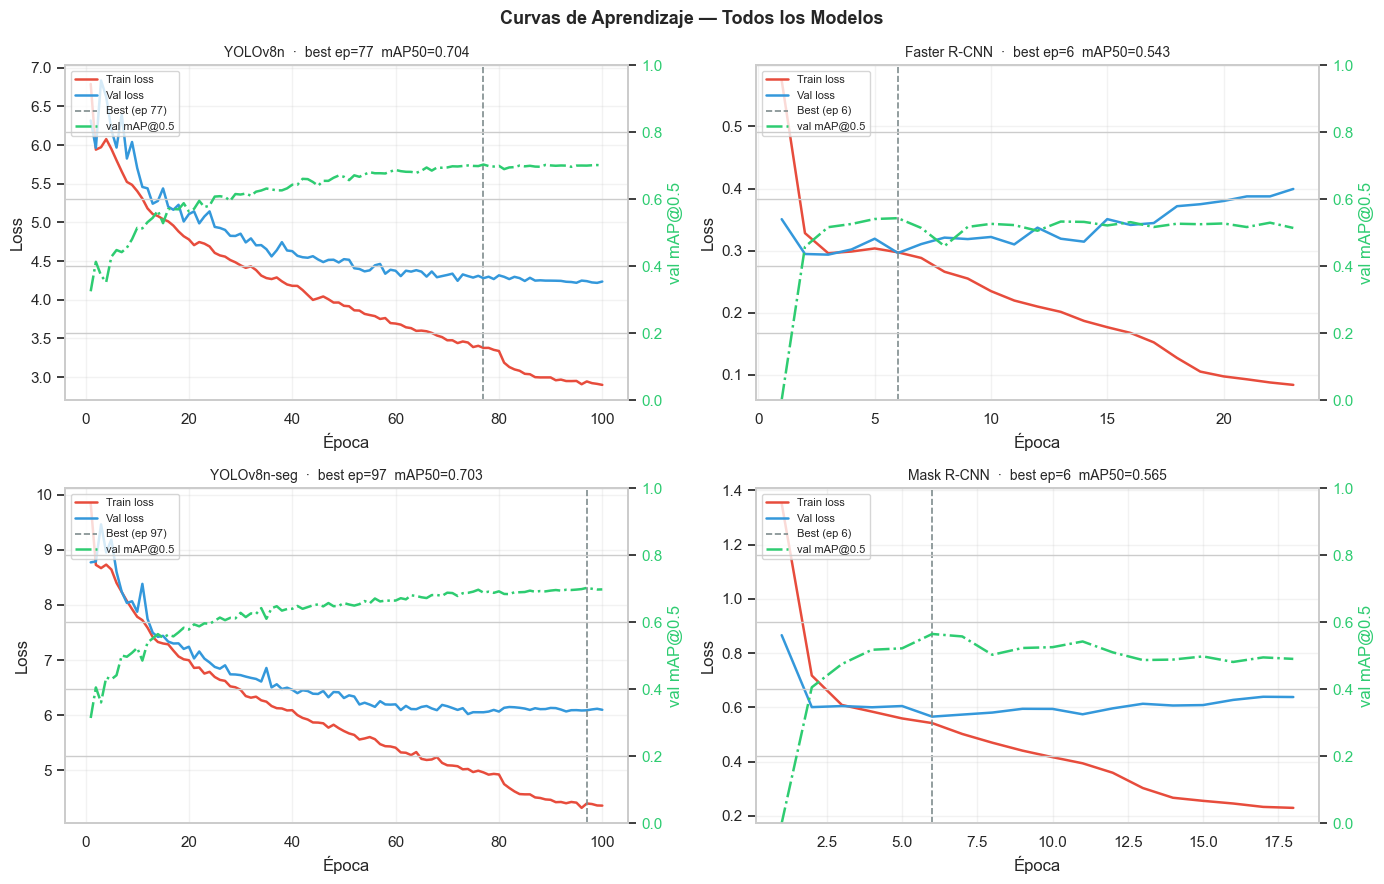

Guardado en c:\proyectos python\Tesis 2026\Proyecto\artifacts\figures\learning_curves.png


In [43]:
import pandas as pd

def _load_rcnn_hist(model_id):
    df = pd.read_csv(METRICS_DIR / f"{model_id}_training_history.csv")
    df['epoch'] = df['epoch'].astype(int)
    return df[['epoch', 'train_loss', 'val_loss', 'val_map50']].copy()

def _load_yolo_hist(run_name, map_col, train_cols, val_cols):
    df = pd.read_csv(ARTIFACTS_DIR / "runs" / run_name / "results.csv")
    df.columns = df.columns.str.strip()
    df['epoch'] = pd.to_numeric(df['epoch'], errors='coerce')
    df = df.dropna(subset=['epoch'])
    df['epoch'] = df['epoch'].astype(int)
    # Ultralytics appends to results.csv with exist_ok=True — detect last run start
    resets = df.index[df['epoch'] == 1].tolist()
    if len(resets) > 1:
        df = df.iloc[resets[-1]:].reset_index(drop=True)
    df['train_loss'] = df[train_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1)
    df['val_loss'] = df[val_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1)
    df['val_map50'] = pd.to_numeric(df[map_col], errors='coerce')
    return df[['epoch', 'train_loss', 'val_loss', 'val_map50']].dropna()

_HIST_SPECS = [
    ("yolov8_det",  "YOLOv8n",      "detection",
     lambda: _load_yolo_hist("yolov8_det_train", "metrics/mAP50(B)",
                             ["train/box_loss", "train/cls_loss", "train/dfl_loss"],
                             ["val/box_loss",   "val/cls_loss",   "val/dfl_loss"])),
    ("faster_rcnn", "Faster R-CNN", "detection",   lambda: _load_rcnn_hist("faster_rcnn")),
    ("yolov8_seg",  "YOLOv8n-seg",  "segmentation",
     lambda: _load_yolo_hist("yolov8_seg_train", "metrics/mAP50(M)",
                             ["train/box_loss", "train/seg_loss", "train/cls_loss", "train/dfl_loss"],
                             ["val/box_loss",   "val/seg_loss",   "val/cls_loss",   "val/dfl_loss"])),
    ("mask_rcnn",   "Mask R-CNN",   "segmentation", lambda: _load_rcnn_hist("mask_rcnn")),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Curvas de Aprendizaje \u2014 Todos los Modelos", fontsize=13, fontweight="bold")

_CLR = {"train": "#e74c3c", "val": "#3498db", "map50": "#2ecc71", "best": "#7f8c8d"}

for ax, (model_id, display_name, task, loader) in zip(axes.flatten(), _HIST_SPECS):
    df = loader()
    best_idx  = df["val_map50"].idxmax()
    best_epoch = int(df.loc[best_idx, "epoch"])
    best_map   = float(df.loc[best_idx, "val_map50"])

    ax.plot(df["epoch"], df["train_loss"], color=_CLR["train"], lw=1.8, label="Train loss")
    ax.plot(df["epoch"], df["val_loss"],   color=_CLR["val"],   lw=1.8, label="Val loss")
    ax.axvline(best_epoch, color=_CLR["best"], ls="--", lw=1.2, label=f"Best (ep {best_epoch})")
    ax.set_xlabel("\u00c9poca")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.25)

    ax2 = ax.twinx()
    ax2.plot(df["epoch"], df["val_map50"], color=_CLR["map50"], lw=1.8, ls="-.",
             label="val mAP@0.5")
    ax2.set_ylabel("val mAP@0.5", color=_CLR["map50"])
    ax2.tick_params(axis="y", labelcolor=_CLR["map50"])
    ax2.set_ylim(0, 1)

    ax.set_title(f"{display_name}  \u00b7  best ep={best_epoch}  mAP50={best_map:.3f}", fontsize=10)
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc="upper left")

plt.tight_layout()
_lc_path = FIGURES_DIR / "learning_curves.png"
plt.savefig(_lc_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Guardado en {_lc_path}")


## 14. Comparación Entre Enfoques


In [44]:
APPROACH_COMPARISON_DF = pd.DataFrame(
    [
        {
            "enfoque": "Detección",
            "salida": "Bounding boxes",
            "fortaleza": "Menor costo computacional y mayor simplicidad",
            "limitación": "Menor precisión espacial en daños irregulares",
            "utilidad_demo_web": "Alta",
        },
        {
            "enfoque": "Segmentación",
            "salida": "Máscaras por instancia",
            "fortaleza": "Delimitación fina y mayor interpretabilidad visual",
            "limitación": "Más costo de cómputo e integración",
            "utilidad_demo_web": "Media-Alta",
        },
    ]
)
APPROACH_COMPARISON_DF


,enfoque,salida,fortaleza,limitación,utilidad_demo_web
0,Detección,Bounding boxes,Menor costo computacional y mayor simplicidad,Menor precisión espacial en daños irregulares,Alta
1,Segmentación,Máscaras por instancia,Delimitación fina y mayor interpretabilidad vi...,Más costo de cómputo e integración,Media-Alta


## 14.1 Comparación Gráfica

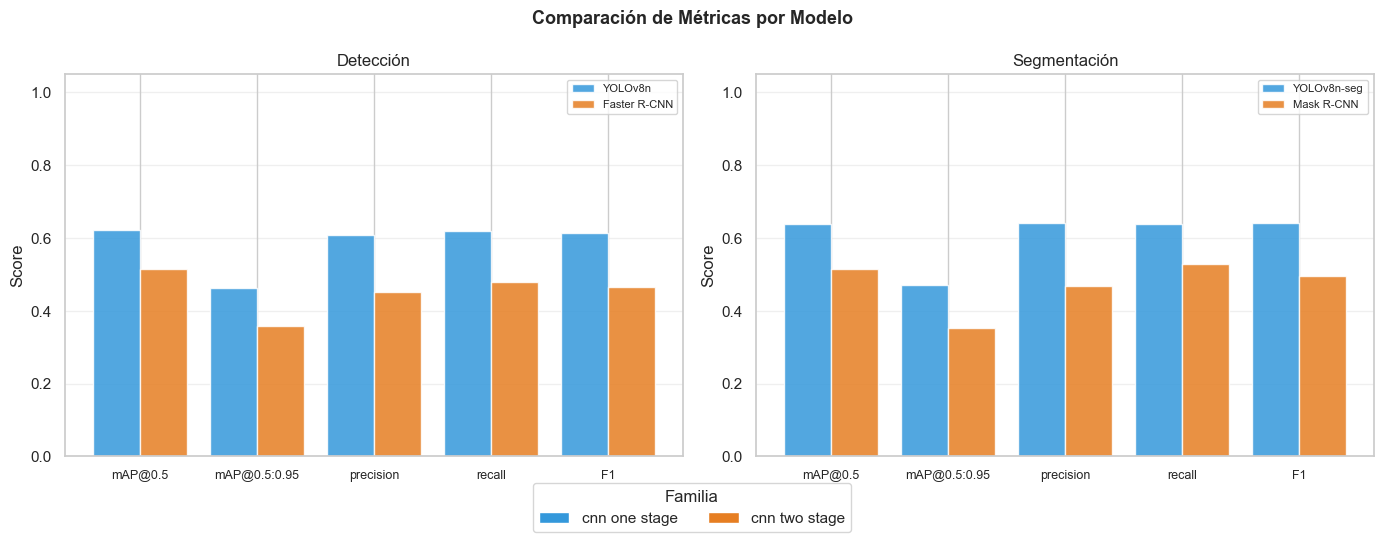

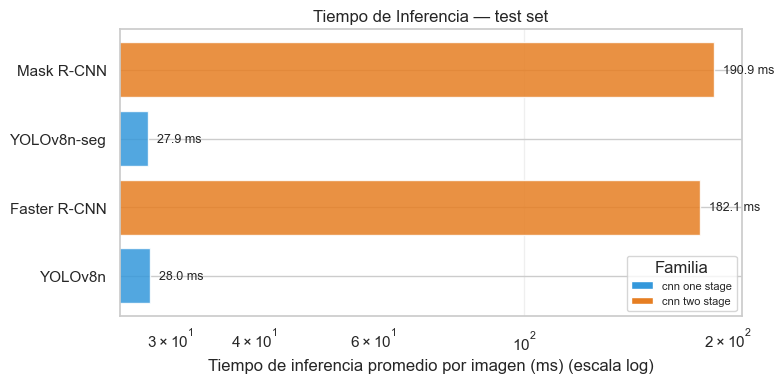

In [45]:
import numpy as np

_FAMILY_COLORS = {"cnn_one_stage": "#3498db", "cnn_two_stage": "#e67e22"}
_METRICS = ["mAP@0.5", "mAP@0.5:0.95", "precision", "recall", "F1"]

def _metric_bar_chart(df, ax, title):
    if df.empty:
        ax.set_title(f"{title} (sin datos)")
        return
    models   = df["display_name"].tolist()
    families = df["family"].tolist()
    n_mod, n_m = len(models), len(_METRICS)
    width = 0.8 / n_mod
    x = np.arange(n_m)
    for i, (model, fam) in enumerate(zip(models, families)):
        vals = [float(df.loc[df["display_name"] == model, m].values[0]) for m in _METRICS]
        ax.bar(x + i * width - 0.4 + width / 2, vals, width,
               label=model, color=_FAMILY_COLORS.get(fam, "#95a5a6"), alpha=0.85, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(_METRICS, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparaci\u00f3n de M\u00e9tricas por Modelo", fontsize=13, fontweight="bold")
_metric_bar_chart(DETECTION_COMPARISON_DF,    axes[0], "Detecci\u00f3n")
_metric_bar_chart(SEGMENTATION_COMPARISON_DF, axes[1], "Segmentaci\u00f3n")

from matplotlib.patches import Patch
_fam_legend = [Patch(facecolor=c, label=f.replace("_", " ")) for f, c in _FAMILY_COLORS.items()]
fig.legend(handles=_fam_legend, title="Familia", loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
fig.savefig(FIGURES_DIR / "comparison_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

_all_df = pd.concat([DETECTION_COMPARISON_DF, SEGMENTATION_COMPARISON_DF], ignore_index=True)
if not _all_df.empty:
    fig2, ax2 = plt.subplots(figsize=(8, 4))
    _names  = _all_df["display_name"].tolist()
    _times  = _all_df["inference_time_ms"].tolist()
    _colors = [_FAMILY_COLORS.get(f, "#95a5a6") for f in _all_df["family"].tolist()]
    _bars   = ax2.barh(_names, _times, color=_colors, alpha=0.85, edgecolor="white")
    xlabel  = "Tiempo de inferencia promedio por imagen (ms)"
    _pos_times = [t for t in _times if t > 0]
    if _pos_times and max(_times) / min(_pos_times) > 5:
        ax2.set_xscale("log")
        xlabel += " (escala log)"
    ax2.set_xlabel(xlabel)
    ax2.set_title("Tiempo de Inferencia \u2014 test set")
    for bar, t in zip(_bars, _times):
        ax2.text(bar.get_width() * 1.03, bar.get_y() + bar.get_height() / 2,
                 f"{t:.1f} ms", va="center", fontsize=9)
    ax2.legend(handles=_fam_legend, title="Familia", fontsize=8)
    ax2.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    fig2.savefig(FIGURES_DIR / "comparison_inference_time.png", dpi=150, bbox_inches="tight")
    plt.show()


## 15. Análisis de Errores


In [46]:
def build_error_summary(predictions: List[Dict[str, Any]], split_name: str, task: str, iou_threshold: float = 0.5) -> pd.DataFrame:
    gt_records = build_ground_truth_records(split_name, task)
    gt_by_image_class = {}
    for gt in gt_records:
        gt_by_image_class.setdefault((gt["image_id"], gt["category_id"]), []).append({**gt, "matched": False})
    rows = []
    for pred in sorted(predictions, key=lambda x: x.get("score", 0.0), reverse=True):
        candidates = gt_by_image_class.get((pred["image_id"], pred["category_id"]), [])
        best_iou = 0.0
        best_idx = None
        for idx, gt in enumerate(candidates):
            if gt["matched"]:
                continue
            iou = box_iou_np(pred["bbox"], gt["bbox"]) if task == "detection" else mask_iou_np(pred["mask"], gt["mask"])
            if iou > best_iou:
                best_iou = iou
                best_idx = idx
        if best_idx is not None and best_iou >= iou_threshold:
            candidates[best_idx]["matched"] = True
        else:
            rows.append({"error_type": "false_positive", "class_name": CATEGORY_ID_TO_NAME[pred["category_id"]]})
    for _, gts in gt_by_image_class.items():
        for gt in gts:
            if not gt["matched"]:
                rows.append({"error_type": "false_negative", "class_name": CATEGORY_ID_TO_NAME[gt["category_id"]]})
    return pd.DataFrame(rows).groupby(["error_type", "class_name"]).size().reset_index(name="count") if rows else pd.DataFrame()


def false_positive_score_distribution(predictions, split_name, task, iou_threshold=0.5):
    """Distribución de scores de falsos positivos.
    Si la mayoría tiene score bajo (~0.25-0.4) → umbral permisivo es la causa principal.
    Si una fracción alta tiene score alto (>=0.7) → el modelo genuinamente confunde clases.
    """
    gt_records = build_ground_truth_records(split_name, task)
    gt_by_image_class = {}
    for gt in gt_records:
        gt_by_image_class.setdefault((gt["image_id"], gt["category_id"]), []).append({**gt, "matched": False})

    fp_scores = []
    for pred in sorted(predictions, key=lambda x: x.get("score", 0.0), reverse=True):
        candidates = gt_by_image_class.get((pred["image_id"], pred["category_id"]), [])
        best_iou, best_idx = 0.0, None
        for idx, gt in enumerate(candidates):
            if gt["matched"]:
                continue
            iou = box_iou_np(pred["bbox"], gt["bbox"]) if task == "detection" else mask_iou_np(pred["mask"], gt["mask"])
            if iou > best_iou:
                best_iou, best_idx = iou, idx
        if best_idx is not None and best_iou >= iou_threshold:
            candidates[best_idx]["matched"] = True
        else:
            fp_scores.append(pred.get("score", 0.0))

    fp_scores = np.array(fp_scores)
    if len(fp_scores) == 0:
        print("  Sin falsos positivos.")
        return
    percentiles = [10, 25, 50, 75, 90, 95, 99]
    print(f"  N falsos positivos: {len(fp_scores)}")
    print(f"  Percentiles de score de los FP: { {p: round(float(np.percentile(fp_scores, p)), 3) for p in percentiles} }")
    print(f"  % FP con score < 0.4 (posiblemente poda con umbral): {(fp_scores < 0.4).mean()*100:.1f}%")
    print(f"  % FP con score >= 0.7 (alta confianza — no es solo umbral): {(fp_scores >= 0.7).mean()*100:.1f}%")


def cross_class_overlap_summary(predictions, split_name, task, iou_threshold=0.5, cross_iou_threshold=0.3):
    """De los falsos positivos (según matching por clase), cuántos caen encima
    de un daño real de una clase distinta — indicio de confusión entre clases
    y/o NMS-per-class dejando pasar hipótesis competidoras sobre la misma región.
    """
    gt_records = build_ground_truth_records(split_name, task)
    gt_by_image_class = {}
    gt_by_image_any = {}
    for gt in gt_records:
        gt_by_image_class.setdefault((gt["image_id"], gt["category_id"]), []).append({**gt, "matched": False})
        gt_by_image_any.setdefault(gt["image_id"], []).append(gt)

    cross_class_fp = 0
    background_fp = 0
    for pred in sorted(predictions, key=lambda x: x.get("score", 0.0), reverse=True):
        candidates = gt_by_image_class.get((pred["image_id"], pred["category_id"]), [])
        best_iou, best_idx = 0.0, None
        for idx, gt in enumerate(candidates):
            if gt["matched"]:
                continue
            iou = box_iou_np(pred["bbox"], gt["bbox"]) if task == "detection" else mask_iou_np(pred["mask"], gt["mask"])
            if iou > best_iou:
                best_iou, best_idx = iou, idx
        if best_idx is not None and best_iou >= iou_threshold:
            candidates[best_idx]["matched"] = True
            continue
        # Es FP — revisar si hay un GT de OTRA clase cerca
        other_gts = [g for g in gt_by_image_any.get(pred["image_id"], []) if g["category_id"] != pred["category_id"]]
        overlaps_other = any(
            (box_iou_np(pred["bbox"], g["bbox"]) if task == "detection" else mask_iou_np(pred["mask"], g["mask"])) >= cross_iou_threshold
            for g in other_gts
        )
        if overlaps_other:
            cross_class_fp += 1
        else:
            background_fp += 1

    total = cross_class_fp + background_fp
    if total == 0:
        print("  Sin falsos positivos.")
        return
    print(f"  FP totales: {total}")
    print(f"  Sobre daño real de OTRA clase (posible colisión NMS-per-class): {cross_class_fp} ({cross_class_fp/total*100:.1f}%)")
    print(f"  Sobre fondo / sin daño real cerca: {background_fp} ({background_fp/total*100:.1f}%)")


if TRAINING_EXECUTION["run_error_analysis"]:
    import pickle

    # ── 1. Tabla de errores por clase (full) ──────────────────────────────────
    ERROR_SUMMARIES = {}
    for spec in MODEL_SPECS:
        prediction_file = PREDICTIONS_DIR / f"{spec['model_id']}_test_predictions.pkl"
        if not prediction_file.exists():
            continue
        with prediction_file.open("rb") as fh:
            predictions = pickle.load(fh)
        ERROR_SUMMARIES[spec["model_id"]] = build_error_summary(predictions, "test", spec["task"])
        print(f"\n=== Error summary: {spec['display_name']} ===")
        display(ERROR_SUMMARIES[spec["model_id"]])

    # ── 2. Score distribution de FP + cross-class overlap (faster_rcnn / mask_rcnn) ──
    for model_id, task in [("faster_rcnn", "detection"), ("mask_rcnn", "segmentation")]:
        prediction_file = PREDICTIONS_DIR / f"{model_id}_test_predictions.pkl"
        if not prediction_file.exists():
            print(f"[WARN] {prediction_file} no encontrado.")
            continue
        with prediction_file.open("rb") as fh:
            preds = pickle.load(fh)
        print(f"\n=== Diagnóstico de FP: {model_id} ===")
        print("-- Distribución de scores de falsos positivos --")
        false_positive_score_distribution(preds, "test", task)
        print("-- FP que caen sobre daño real de otra clase --")
        cross_class_overlap_summary(preds, "test", task)
else:
    print("Análisis de errores preparado. Active TRAINING_EXECUTION['run_error_analysis']=True para ejecutarlo.")



=== Error summary: YOLOv8n ===


,error_type,class_name,count
0,false_negative,crack,41
1,false_negative,dent,95
2,false_negative,lamp broken,21
3,false_negative,scratch,136
4,false_negative,tire flat,5
5,false_positive,crack,23
6,false_positive,dent,118
7,false_positive,glass shatter,6
8,false_positive,lamp broken,12
9,false_positive,scratch,152



=== Error summary: Faster R-CNN ===


,error_type,class_name,count
0,false_negative,crack,44
1,false_negative,dent,159
2,false_negative,glass shatter,6
3,false_negative,lamp broken,11
4,false_negative,scratch,184
5,false_negative,tire flat,5
6,false_positive,crack,54
7,false_positive,dent,115
8,false_positive,glass shatter,18
9,false_positive,lamp broken,108



=== Error summary: YOLOv8n-seg ===


,error_type,class_name,count
0,false_negative,crack,36
1,false_negative,dent,91
2,false_negative,glass shatter,2
3,false_negative,lamp broken,24
4,false_negative,scratch,126
5,false_negative,tire flat,4
6,false_positive,crack,34
7,false_positive,dent,98
8,false_positive,glass shatter,5
9,false_positive,lamp broken,16



=== Error summary: Mask R-CNN ===


,error_type,class_name,count
0,false_negative,crack,45
1,false_negative,dent,135
2,false_negative,glass shatter,6
3,false_negative,lamp broken,29
4,false_negative,scratch,150
5,false_negative,tire flat,6
6,false_positive,crack,62
7,false_positive,dent,90
8,false_positive,glass shatter,6
9,false_positive,lamp broken,41



=== Diagnóstico de FP: faster_rcnn ===
-- Distribución de scores de falsos positivos --
  N falsos positivos: 457
  Percentiles de score de los FP: {10: 0.441, 25: 0.503, 50: 0.627, 75: 0.793, 90: 0.902, 95: 0.945, 99: 0.975}
  % FP con score < 0.4 (posiblemente poda con umbral): 0.0%
  % FP con score >= 0.7 (alta confianza — no es solo umbral): 38.7%
-- FP que caen sobre daño real de otra clase --
  FP totales: 457
  Sobre daño real de OTRA clase (posible colisión NMS-per-class): 100 (21.9%)
  Sobre fondo / sin daño real cerca: 357 (78.1%)

=== Diagnóstico de FP: mask_rcnn ===
-- Distribución de scores de falsos positivos --
  N falsos positivos: 470
  Percentiles de score de los FP: {10: 0.458, 25: 0.556, 50: 0.748, 75: 0.907, 90: 0.972, 95: 0.986, 99: 0.997}
  % FP con score < 0.4 (posiblemente poda con umbral): 0.0%
  % FP con score >= 0.7 (alta confianza — no es solo umbral): 56.6%
-- FP que caen sobre daño real de otra clase --
  FP totales: 470
  Sobre daño real de OTRA clase (

## 15.1 Visualización de Predicciones

Imagen elegida al azar: 000033.jpg (id=33)


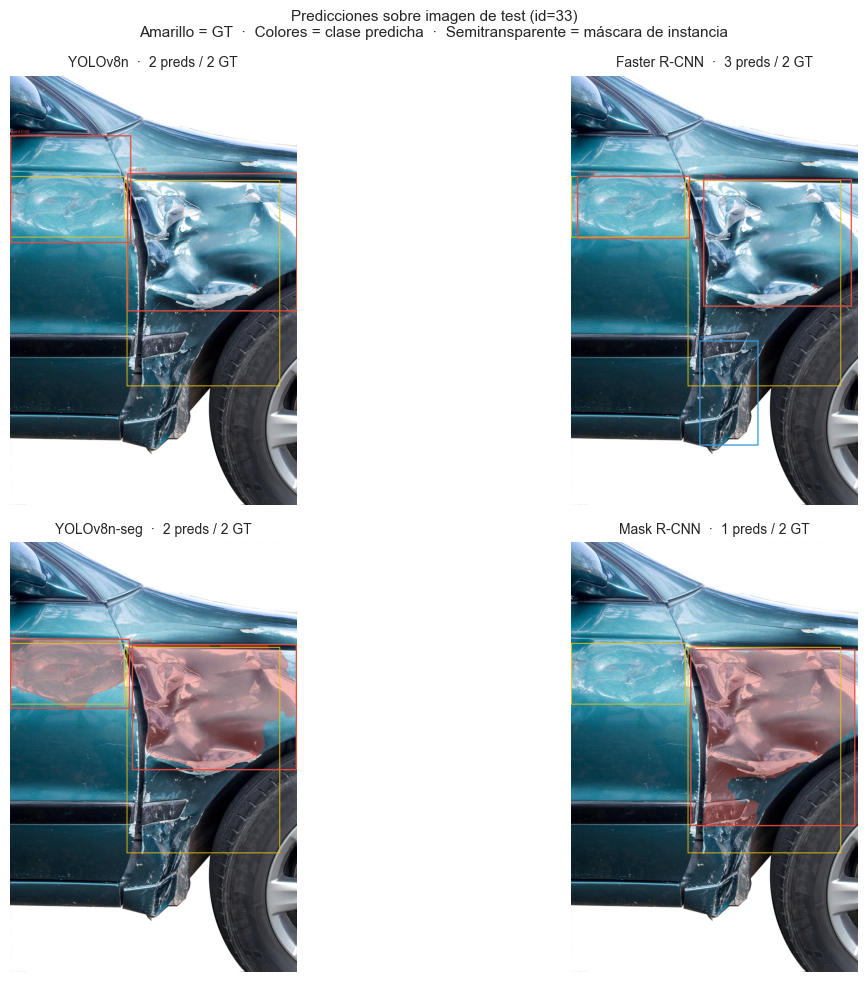

Guardado en c:\proyectos python\Tesis 2026\Proyecto\artifacts\figures\example_predictions.png


In [47]:
import random
import pickle
import numpy as np
from PIL import Image, ImageDraw

_VIZ_PALETTE = [(231, 76, 60), (52, 152, 219), (46, 204, 113),
                (155, 89, 182), (241, 196, 15), (230, 126, 34)]
_VIZ_COLORS = {cat_id: _VIZ_PALETTE[i % len(_VIZ_PALETTE)]
               for i, cat_id in enumerate(sorted(CATEGORY_ID_TO_NAME.keys()))}

def _render_prediction_image(image_path, gt_recs, pred_recs, task):
    """GT (amarillo) + predicciones (color por clase). Masks semitransparentes para seg."""
    img = Image.open(image_path).convert("RGB")
    if task == "segmentation":
        overlay = img.convert("RGBA")
        for pred in pred_recs:
            mask = pred.get("mask")
            if mask is None:
                continue
            r, g, b = _VIZ_COLORS.get(pred["category_id"], (180, 180, 180))
            mask_rgba = np.zeros((*mask.shape, 4), dtype=np.uint8)
            mask_rgba[mask.astype(bool)] = [r, g, b, 100]
            overlay = Image.alpha_composite(overlay, Image.fromarray(mask_rgba, "RGBA"))
        img = overlay.convert("RGB")
    draw = ImageDraw.Draw(img)
    for gt in gt_recs:
        x1, y1, x2, y2 = (int(v) for v in gt["bbox"])
        draw.rectangle([x1, y1, x2, y2], outline="#f1c40f", width=2)
    for pred in pred_recs:
        x1, y1, x2, y2 = (int(v) for v in pred["bbox"])
        r, g, b = _VIZ_COLORS.get(pred["category_id"], (180, 180, 180))
        color = f"#{r:02x}{g:02x}{b:02x}"
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        label = f"{CATEGORY_ID_TO_NAME.get(pred['category_id'], '?')} {pred.get('score', 0):.2f}"
        draw.text((x1 + 2, max(0, y1 - 14)), label, fill=color)
    return img

def _gt_for_image(image_id, task, split="test"):
    """GT records para una sola imagen, sin procesar todo el split."""
    payload = FINAL_SPLIT_PAYLOADS[split]
    images_by_id = {int(img["id"]): img for img in payload["images"]}
    img_meta = images_by_id.get(image_id)
    if img_meta is None:
        return []
    records = []
    for ann in payload["annotations"]:
        if int(ann["image_id"]) != image_id:
            continue
        x, y, w, h = ann["bbox"]
        rec = {"image_id": image_id, "category_id": int(ann["category_id"]),
               "bbox": np.array([x, y, x + w, y + h], dtype=np.float32)}
        if task == "segmentation":
            rec["mask"] = annotation_to_binary_mask(
                ann, int(img_meta["width"]), int(img_meta["height"])).astype(np.uint8)
        records.append(rec)
    return records

_pred_data = {}
for _spec in MODEL_SPECS:
    _pkl = PREDICTIONS_DIR / f"{_spec['model_id']}_test_predictions.pkl"
    if _pkl.exists():
        with _pkl.open("rb") as _fh:
            _pred_data[_spec["model_id"]] = pickle.load(_fh)

_ids_with_preds = set()
for _preds in _pred_data.values():
    _ids_with_preds.update(p["image_id"] for p in _preds)
_candidates = [img for img in FINAL_SPLIT_PAYLOADS["test"]["images"]
               if int(img["id"]) in _ids_with_preds]

_chosen_meta = random.choice(_candidates)
_chosen_id   = int(_chosen_meta["id"])
_chosen_path = resolve_image_path(_chosen_meta.get("file_name", ""))
print(f"Imagen elegida al azar: {_chosen_meta.get('file_name', '')} (id={_chosen_id})")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f"Predicciones sobre imagen de test (id={_chosen_id})\n"
    "Amarillo = GT  \u00b7  Colores = clase predicha  \u00b7  Semitransparente = m\u00e1scara de instancia",
    fontsize=11)
for _ax, _spec in zip(axes.flatten(), MODEL_SPECS):
    _mid       = _spec["model_id"]
    _preds_img = [p for p in _pred_data.get(_mid, []) if p["image_id"] == _chosen_id]
    _gt_img    = _gt_for_image(_chosen_id, _spec["task"])
    _rendered  = _render_prediction_image(_chosen_path, _gt_img, _preds_img, _spec["task"])
    _ax.imshow(_rendered)
    _ax.set_title(f"{_spec['display_name']}  \u00b7  {len(_preds_img)} preds / {len(_gt_img)} GT",
                  fontsize=10)
    _ax.axis("off")

plt.tight_layout()
_viz_path = FIGURES_DIR / "example_predictions.png"
plt.savefig(_viz_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Guardado en {_viz_path}")


## 16. Exportación de Artefactos


In [48]:
def export_model_registry() -> List[Dict[str, Any]]:
    registry = []
    for spec in MODEL_SPECS:
        weights_path = Path(spec["config"]["output_path"])
        registry.append(
            {
                "id": spec["model_id"],
                "display_name": spec["display_name"],
                "task": spec["task"],
                "backend": "ultralytics" if spec["model_id"].startswith("yolov8") else "torchvision",
                "weight_file": weights_path.name,
                "weight_path": str(weights_path),
                "prediction_dump": str(PREDICTIONS_DIR / f"{spec['model_id']}_test_predictions.pkl"),
            }
        )
    registry_path = MODELS_DIR / "model_registry.json"
    registry_path.write_text(json.dumps({"models": registry, "classes": CATEGORY_ID_TO_NAME}, indent=2), encoding="utf-8")
    return registry

MODEL_REGISTRY = export_model_registry()
pd.DataFrame(MODEL_REGISTRY)


,id,display_name,task,backend,weight_file,weight_path,prediction_dump
0,yolov8_det,YOLOv8n,detection,ultralytics,yolov8_det.pt,c:\proyectos python\Tesis 2026\Proyecto\artifa...,c:\proyectos python\Tesis 2026\Proyecto\artifa...
1,faster_rcnn,Faster R-CNN,detection,torchvision,faster_rcnn.pth,c:\proyectos python\Tesis 2026\Proyecto\artifa...,c:\proyectos python\Tesis 2026\Proyecto\artifa...
2,yolov8_seg,YOLOv8n-seg,segmentation,ultralytics,yolov8_seg.pt,c:\proyectos python\Tesis 2026\Proyecto\artifa...,c:\proyectos python\Tesis 2026\Proyecto\artifa...
3,mask_rcnn,Mask R-CNN,segmentation,torchvision,mask_rcnn.pth,c:\proyectos python\Tesis 2026\Proyecto\artifa...,c:\proyectos python\Tesis 2026\Proyecto\artifa...


## 17. Funciones Reutilizables para Futura Demo


In [49]:
def load_demo_model(model_id: str):
    registry = {item["id"]: item for item in MODEL_REGISTRY}
    spec = registry[model_id]
    if model_id.startswith("yolov8"):
        if ultralytics is None:
            raise ImportError("Ultralytics no está instalado.")
        from ultralytics import YOLO
        return YOLO(spec["weight_path"])
    if model_id == "faster_rcnn":
        return load_torchvision_inference_model("faster_rcnn", FASTERRCNN_CONFIG)
    if model_id == "mask_rcnn":
        return load_torchvision_inference_model("mask_rcnn", MASKRCNN_CONFIG)
    raise KeyError(model_id)

def demo_predict(model_id: str, image_path: Path):
    model = load_demo_model(model_id)
    if model_id.startswith("yolov8"):
        return model.predict(source=str(image_path), verbose=False, conf=0.25, device=0 if DEVICE_INFO["cuda_available"] else "cpu")[0]
    image = Image.open(image_path).convert("RGB")
    image_tensor = pil_to_float_tensor(image).to(torch.device(DEVICE_INFO["device"]))
    with torch.no_grad():
        return model([image_tensor])[0]


## 18. Conclusiones Técnicas


In [50]:
_SUMMARY_METRICS = [
    ("mAP@0.5",          False),
    ("mAP@0.5:0.95",     False),
    ("precision",        False),
    ("recall",           False),
    ("F1",               False),
    ("mean_IoU",         False),
    ("inference_time_ms", True),   # lower is better
]

def summarize_results(df: pd.DataFrame, task_name: str) -> None:
    """Tabla completa de métricas para todos los modelos de una tarea.
    Marca el mejor valor por columna con * y declara el ganador global
    (mayor mAP@0.5:0.95) y el modelo más rápido en inferencia.
    """
    if df.empty:
        print(f"No hay resultados persistidos todavía para {task_name}.")
        return

    df_s = df.sort_values("mAP@0.5:0.95", ascending=False).reset_index(drop=True)

    COL_LABELS = {
        "mAP@0.5":           "mAP@0.5",
        "mAP@0.5:0.95":      "mAP@0.5:0.95",
        "precision":         "Precision",
        "recall":            "Recall",
        "F1":                "F1",
        "mean_IoU":          "mIoU",
        "inference_time_ms": "Tiempo(ms)",
    }
    NAME_W, COL_W = 14, 13
    sep = "-" * (NAME_W + COL_W * len(_SUMMARY_METRICS))

    # best value per metric
    best = {}
    for col, lower_better in _SUMMARY_METRICS:
        vals = pd.to_numeric(df_s[col], errors="coerce").dropna()
        best[col] = vals.min() if lower_better else vals.max() if not vals.empty else None

    print(f"{'='*70}")
    print(f"  Comparación de modelos — {task_name.upper()}")
    print(f"{'='*70}")

    # header
    print(f"{'Modelo':<{NAME_W}}", end="")
    for col, _ in _SUMMARY_METRICS:
        print(f"{COL_LABELS[col]:>{COL_W}}", end="")
    print()
    print(sep)

    for _, row in df_s.iterrows():
        print(f"{str(row['display_name']):<{NAME_W}}", end="")
        for col, _ in _SUMMARY_METRICS:
            try:
                val = float(row[col])
                is_nan = False
            except (TypeError, ValueError):
                is_nan = True

            if is_nan:
                cell_str = "N/A"
                marker = " "
            else:
                cell_str = f"{val:.1f}" if col == "inference_time_ms" else f"{val:.4f}"
                marker = "*" if (best[col] is not None and abs(val - best[col]) < 1e-9) else " "
            print(f"{cell_str + marker:>{COL_W}}", end="")
        print()

    print(sep)
    print("  * = mejor valor en esa métrica")

    # overall winner (mAP@0.5:0.95)
    best_row = df_s.iloc[0]
    print(f"\n  Mejor modelo global ({task_name}): {best_row['display_name']}")
    print(f"    mAP@0.5={best_row['mAP@0.5']:.4f}  "
          f"mAP@0.5:0.95={best_row['mAP@0.5:0.95']:.4f}  "
          f"Precision={best_row['precision']:.4f}  "
          f"Recall={best_row['recall']:.4f}  "
          f"F1={best_row['F1']:.4f}")

    # fastest
    t_col = pd.to_numeric(df_s["inference_time_ms"], errors="coerce")
    if not t_col.isna().all():
        fast_idx = t_col.idxmin()
        fast_row = df_s.loc[fast_idx]
        if fast_row["display_name"] != best_row["display_name"]:
            print(f"  Más rápido en inferencia: {fast_row['display_name']} "
                  f"({fast_row['inference_time_ms']:.1f} ms  vs  "
                  f"{best_row['inference_time_ms']:.1f} ms del mejor por mAP)")

    # precision winner (useful for FP diagnostic context)
    prec_col = pd.to_numeric(df_s["precision"], errors="coerce")
    if not prec_col.isna().all():
        prec_idx = prec_col.idxmax()
        prec_row = df_s.loc[prec_idx]
        if prec_row["display_name"] != best_row["display_name"]:
            print(f"  Mayor precisión (menos FP relativos): {prec_row['display_name']} "
                  f"(precision={prec_row['precision']:.4f})")

    print()


summarize_results(DETECTION_COMPARISON_DF, "detección")
summarize_results(SEGMENTATION_COMPARISON_DF, "segmentación")
print("La comparación entre enfoques debe discutirse junto con costo de inferencia, fidelidad espacial y utilidad para una futura demo web.")


  Comparación de modelos — DETECCIÓN
Modelo              mAP@0.5 mAP@0.5:0.95    Precision       Recall           F1         mIoU   Tiempo(ms)
---------------------------------------------------------------------------------------------------------
YOLOv8n             0.6221*      0.4612*      0.6088*      0.6204*      0.6145*      0.8114*        28.0*
Faster R-CNN        0.5151       0.3575       0.4514       0.4790       0.4648       0.8038        182.1 
---------------------------------------------------------------------------------------------------------
  * = mejor valor en esa métrica

  Mejor modelo global (detección): YOLOv8n
    mAP@0.5=0.6221  mAP@0.5:0.95=0.4612  Precision=0.6088  Recall=0.6204  F1=0.6145

  Comparación de modelos — SEGMENTACIÓN
Modelo              mAP@0.5 mAP@0.5:0.95    Precision       Recall           F1         mIoU   Tiempo(ms)
---------------------------------------------------------------------------------------------------------
YOLOv8n-seg        